# Additional QC and analysis for paper revision

Requested by reviewers, this notebook contains the following new analyses:

1) Mendelian Inheritance Error
2) Parent of Origine Detection

In [3]:
suppressPackageStartupMessages(library(tidyverse))
suppressMessages(source("../scripts/00_R_presets.R"))
pub_samples <- c(
  "T2T00", "T2T00_1", "T2T00_2",
  "T2T01", "T2T02", "T2T03",
  "T2T04", "T2T04_1", "T2T04_2",
  "T2T05", "T2T06", "T2T07", "T2T08", "T2T09", "T2T10",
  "T2T11", "T2T12", "T2T13",
  "T2T15", "T2T16", "T2T17", "T2T18", "T2T19"
)


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `chr_num = case_when(...)`.
Caused by warning:
! NAs introduced by coercion”


## 1) Mendelian Error analysis

In [43]:
# ── Mendelian error analysis ─────────────────────────────────────────────────
# Raw summary (nmerr / ngood / rate per sample)
miv_summary <- list.files("../../analysis_other/mendelian_qc",
                           pattern = "summary\\.tsv$", recursive = TRUE,
                           full.names = TRUE) |>
  read_tsv(show_col_types = FALSE)

# All evaluated sites with per-site MERR flag
sites <- list.files("../../analysis_other/mendelian_qc",
                    pattern = "sites\\.tsv\\.gz$", recursive = TRUE,
                    full.names = TRUE) |>
  setNames(basename(dirname(
    list.files("../../analysis_other/mendelian_qc",
               pattern = "sites\\.tsv\\.gz$", recursive = TRUE)
  ))) |>
  imap_dfr(~
    read_tsv(.x, col_names = c("chrom", "pos", "ref", "alt", "merr"),
             col_types = "cicii", show_col_types = FALSE) |>
    mutate(sample = .y)
  ) |>
  mutate(is_merr = merr > 0)

# De novo positions: ALT absent from both parents (immune to switch/flip artefacts)
denovo_pos <- list.files("../../analysis_other/mendelian_qc",
                         pattern = "merr\\.vcf\\.gz$", recursive = TRUE,
                         full.names = TRUE) |>
  setNames(basename(dirname(
    list.files("../../analysis_other/mendelian_qc",
               pattern = "merr\\.vcf\\.gz$", recursive = TRUE)
  ))) |>
  imap_dfr(~ {
    cmd <- paste0(
      "bcftools view -i 'GT[1]=\"0/0\" && GT[2]=\"0/0\"' ", .x,
      " 2>/dev/null | bcftools query -f '%CHROM\\t%POS\\n'"
    )
    out <- system(cmd, intern = TRUE)
    if (length(out) == 0)
      return(tibble(chrom = character(), pos = integer()))
    read_tsv(I(out), col_names = c("chrom", "pos"),
             col_types = "ci", show_col_types = FALSE) |>
      mutate(sample = .y)
  })

# Annotate sites with de novo flag
sites <- sites |>
  left_join(denovo_pos |> mutate(is_denovo = TRUE),
            by = c("sample", "chrom", "pos")) |>
  mutate(
    is_denovo  = coalesce(is_denovo, FALSE) & is_merr,
    merr_class = case_when(
      !is_merr  ~ "Consistent",
      is_denovo ~ "De novo",
      TRUE      ~ "Switch/flip"
    )
  )

cat("Sites loaded per sample:\n")
sites |> count(sample, merr_class) |> print()


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message in left_join(sites, mutate(denovo_pos, is_denovo = TRUE), by = c("sample", :
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 5687153 of `x` matches multiple rows in `y`.
ℹ Row 1727 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


Sites loaded per sample:
# A tibble: 6 × 3
  sample merr_class        n
  <chr>  <chr>         <int>
1 T2T00  Consistent  2860749
2 T2T00  De novo       78871
3 T2T00  Switch/flip   40731
4 T2T04  Consistent  2927236
5 T2T04  De novo       67877
6 T2T04  Switch/flip   40353


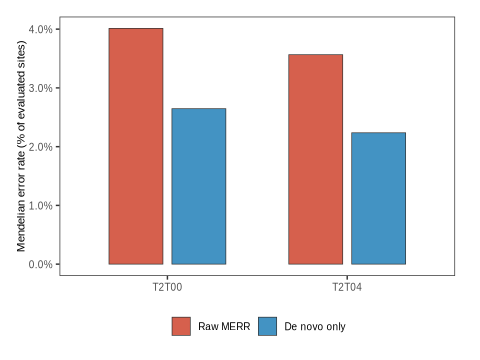

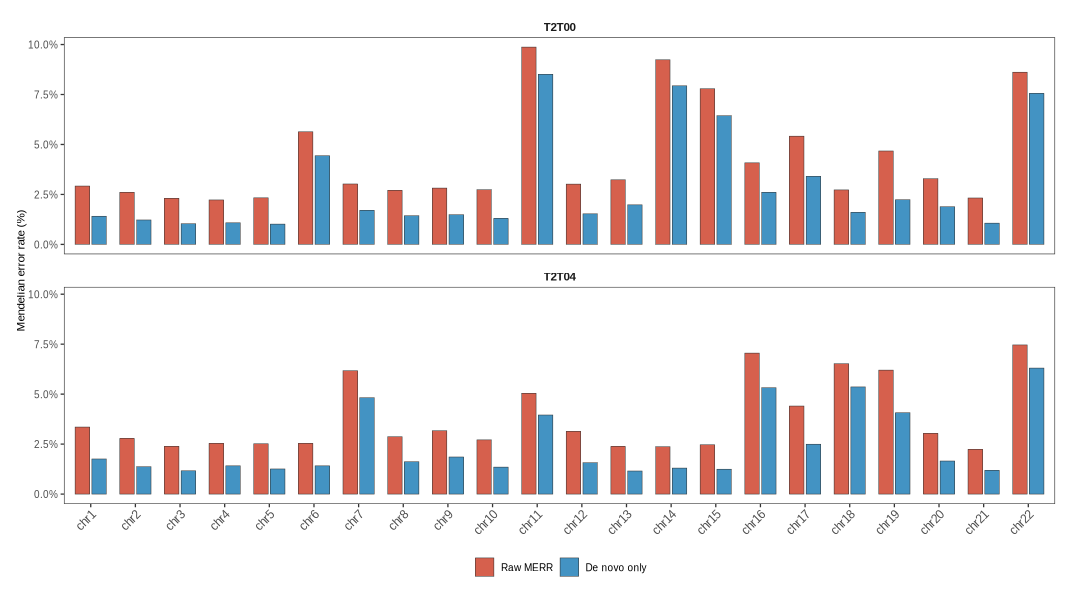

In [44]:
CHR_LEVELS <- levels(karyotype_chm13$chr)

merr_cols <- c(`Raw MERR`  = "#d6604d", `De novo only` = "#4393c3")

# ── 1. Overall rate comparison (raw vs de novo) ───────────────────────────────
overall_rates <- sites |>
  group_by(sample) |>
  summarise(
    n_evaluated = n(),
    n_merr_raw  = sum(is_merr),
    n_merr_dn   = sum(is_denovo),
    .groups     = "drop"
  ) |>
  mutate(
    pct_raw = 100 * n_merr_raw / n_evaluated,
    pct_dn  = 100 * n_merr_dn  / n_evaluated
  ) |>
  pivot_longer(c(pct_raw, pct_dn),
               names_to  = "metric",
               values_to = "pct") |>
  mutate(metric = factor(metric,
                         levels = c("pct_raw", "pct_dn"),
                         labels = c("Raw MERR", "De novo only")))

p_overall <- ggplot(overall_rates,
    aes(x = sample, y = pct, fill = metric)) +
  geom_col(position = position_dodge(width = 0.7), width = 0.6,
           colour = "grey20", linewidth = 0.2) +
  scale_fill_manual(values = merr_cols, name = NULL) +
  scale_y_continuous(labels = scales::label_number(suffix = "%", accuracy = 0.1)) +
  labs(x = NULL, y = "Mendelian error rate (% of evaluated sites)") +
  t2t_theme(base_size = 9) +
  theme(legend.position = "bottom")

ggsave("../../doc/figures/mendelian_overall_rates.pdf", p_overall, width = 4, height = 3)
ggsave("../../doc/figures/mendelian_overall_rates.png", p_overall, width = 4, height = 3, dpi = 300)
options(repr.plot.width = 4, repr.plot.height = 3)
p_overall

# ── 2. Per-chromosome rates ───────────────────────────────────────────────────
chr_rates <- sites |>
  filter(chrom %in% CHR_LEVELS) |>
  mutate(chrom = factor(chrom, levels = CHR_LEVELS)) |>
  group_by(sample, chrom) |>
  summarise(
    n_sites = n(),
    pct_raw = 100 * sum(is_merr)   / n_sites,
    pct_dn  = 100 * sum(is_denovo) / n_sites,
    .groups = "drop"
  ) |>
  pivot_longer(c(pct_raw, pct_dn),
               names_to  = "metric",
               values_to = "pct") |>
  mutate(metric = factor(metric,
                         levels = c("pct_raw", "pct_dn"),
                         labels = c("Raw MERR", "De novo only")))

p_chr <- ggplot(chr_rates,
    aes(x = chrom, y = pct, fill = metric)) +
  geom_col(position = position_dodge(width = 0.75), width = 0.65,
           colour = "grey20", linewidth = 0.15) +
  scale_fill_manual(values = merr_cols, name = NULL) +
  scale_y_continuous(labels = scales::label_number(suffix = "%", accuracy = 0.1)) +
  facet_wrap(~ sample, ncol = 1) +
  labs(x = NULL, y = "Mendelian error rate (%)") +
  t2t_theme(base_size = 8) +
  theme(axis.text.x  = element_text(angle = 45, hjust = 1, size = 7),
        legend.position = "bottom")

ggsave("../../doc/figures/mendelian_chr_rates.pdf", p_chr, width = 9, height = 5)
ggsave("../../doc/figures/mendelian_chr_rates.png", p_chr, width = 9, height = 5, dpi = 300)
options(repr.plot.width = 9, repr.plot.height = 5)
p_chr


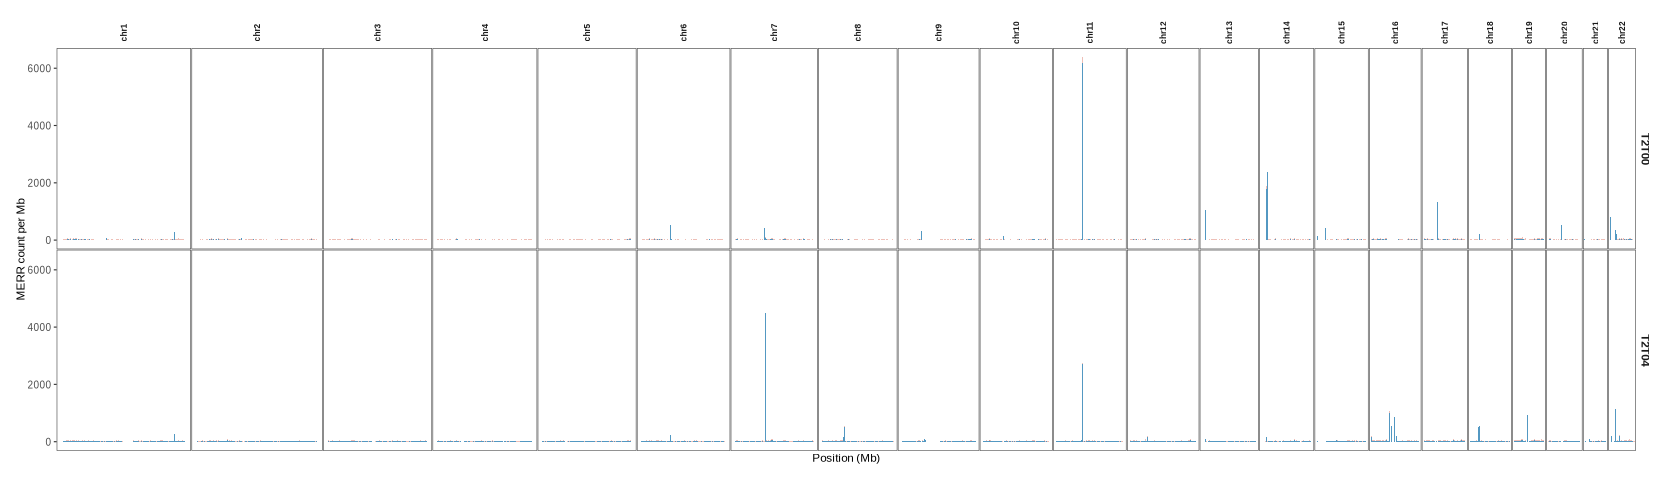

In [45]:
#  Windowed de novo error density across genome
WINDOW_SIZE <- 1e6

windows <- sites |>
  filter(chrom %in% CHR_LEVELS) |>
  mutate(
    chrom  = factor(chrom, levels = CHR_LEVELS),
    win_mb = floor((pos - 1) / WINDOW_SIZE)
  ) |>
  group_by(sample, chrom, win_mb) |>
  summarise(
    n_sites  = n(),
    n_raw    = sum(is_merr),
    n_denovo = sum(is_denovo),
    .groups  = "drop"
  )

# One combined plot faceted by sample × chromosome
p_windows <- ggplot(windows,
    aes(x = win_mb)) +
  geom_col(aes(y = n_raw),    fill = merr_cols["Raw MERR"],    width = 1, alpha = 0.4) +
  geom_col(aes(y = n_denovo), fill = merr_cols["De novo only"], width = 1, alpha = 0.9) +
  facet_grid(sample ~ chrom, scales = "free_x", space = "free_x") +
  labs(x = "Position (Mb)", y = "MERR count per Mb") +
  t2t_theme(base_size = 7) +
  theme(
    axis.text.x   = element_blank(),
    axis.ticks.x  = element_blank(),
    strip.text.x  = element_text(size = 5, angle = 90),
    strip.text.y  = element_text(size = 7),
    panel.spacing = unit(0.3, "pt")
  )

ggsave("../../doc/figures/mendelian_genome_windows.pdf", p_windows, width = 14, height = 4)
ggsave("../../doc/figures/mendelian_genome_windows.png", p_windows, width = 14, height = 4, dpi = 200)
options(repr.plot.width = 14, repr.plot.height = 4)
p_windows


In [46]:
#  Mendelian error summary table
GENOME_SIZE <- 6e9  # diploid bp

merr_table <- sites |>
  group_by(sample) |>
  summarise(
    n_evaluated   = n(),
    n_merr_raw    = sum(is_merr),
    n_merr_switch = sum(merr_class == "Switch/flip"),
    n_merr_denovo = sum(is_denovo),
    pct_raw       = round(100 * n_merr_raw    / n_evaluated, 3),
    pct_switch    = round(100 * n_merr_switch / n_evaluated, 3),
    pct_denovo    = round(100 * n_merr_denovo / n_evaluated, 3),
    qv_raw_sites  = round(-10 * log10(n_merr_raw    / n_evaluated), 1),
    qv_dn_sites   = round(-10 * log10(n_merr_denovo / n_evaluated), 1),
    qv_dn_genome  = round(-10 * log10(n_merr_denovo / GENOME_SIZE), 1),
    .groups       = "drop"
  ) |>
  left_join(miv_summary |> select(sample, nmissing), by = "sample") |>
  arrange(sample)

write_tsv(merr_table, "../../doc/tables/mendelian_error_summary.tsv")
print(merr_table)

cat(sprintf(paste(
  "\n%-30s %8s %8s",
  "%-30s %8.2f%% %8.2f%%",
  "%-30s %8.2f%% %8.2f%%",
  "%-30s %8.1f %8.1f",
  "%-30s %8.1f %8.1f",
  "%-30s %8.1f %8.1f",
  sep = "\n"),
  "", "T2T00", "T2T04",
  "Raw MERR rate",         merr_table$pct_raw[1],      merr_table$pct_raw[2],
  "De novo rate",          merr_table$pct_denovo[1],   merr_table$pct_denovo[2],
  "QV (raw, at var sites)", merr_table$qv_raw_sites[1], merr_table$qv_raw_sites[2],
  "QV (de novo, at var sites)", merr_table$qv_dn_sites[1], merr_table$qv_dn_sites[2],
  "QV (de novo, genome-wide)", merr_table$qv_dn_genome[1], merr_table$qv_dn_genome[2]
))
cat("\n[genome-wide QV uses diploid genome size 6 Gb as denominator]\n")
cat("[compare: Merqury QV ~51, reference-based QV (HG002 non-rep) ~68]\n")


# A tibble: 2 × 12
  sample n_evaluated n_merr_raw n_merr_switch n_merr_denovo pct_raw pct_switch
  <chr>        <int>      <int>         <int>         <int>   <dbl>      <dbl>
1 T2T00      2980351     119602         40731         78871    4.01       1.37
2 T2T04      3035466     108230         40353         67877    3.57       1.33
# ℹ 5 more variables: pct_denovo <dbl>, qv_raw_sites <dbl>, qv_dn_sites <dbl>,
#   qv_dn_genome <dbl>, nmissing <dbl>

                                  T2T00    T2T04
Raw MERR rate                      4.01%     3.57%
De novo rate                       2.65%     2.24%
QV (raw, at var sites)             14.0     14.5
QV (de novo, at var sites)         15.8     16.5
QV (de novo, genome-wide)          48.8     49.5
[genome-wide QV uses diploid genome size 6 Gb as denominator]
[compare: Merqury QV ~51, reference-based QV (HG002 non-rep) ~68]


## 2) Contiguity

### 2a) Contig Ends in multicopy genes

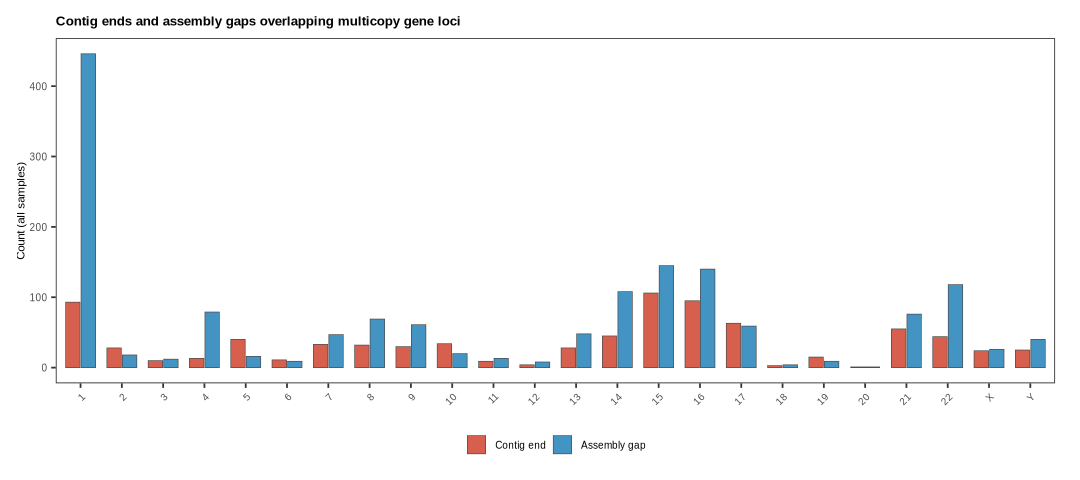

In [5]:
library(tidyverse)

CHR_LEVELS <- levels(karyotype_chm13$chr)

# load contig ends overlapping multicopy gene loci
ce_files <- list.files(
    "../../analysis_other/multicopy_genes",
    pattern  = "contig_ends_to_multicopy_gene_distance\\.tsv$",
    recursive = TRUE, full.names = TRUE
)

dt_ce <- read_tsv(ce_files, show_col_types = FALSE, id = "path") %>%
  filter(distance == 0, haplotype != "unassigned") %>%
  transmute(chr = chrom, sample = basename(dirname(path)), feature = "Contig end")

# load assembly gaps overlapping multicopy gene loci
gap_files <- list.files(
    "../../analysis_other/multicopy_genes",
    pattern  = "gap_to_multicopy_gene_distance\\.tsv$",
    recursive = TRUE, full.names = TRUE
)

dt_gap <- read_tsv(gap_files, show_col_types = FALSE, id = "path") %>%
  filter(distance == 0) %>%
  transmute(chr = chrom, sample = basename(dirname(path)), feature = "Assembly gap")

# combine and count per chromosome
dt_combined <- bind_rows(dt_ce, dt_gap) |>
    filter(chr %in% CHR_LEVELS) |>
    mutate(chr = factor(chr, levels = CHR_LEVELS)) |>
    count(chr, feature) |>
    mutate(feature = factor(feature, levels = c("Contig end", "Assembly gap")))

p_multicopy <- dt_combined |>
    ggplot(aes(x = chr, y = n, fill = feature)) +
    geom_col(position = position_dodge(width = 0.75), width = 0.7,
             colour = "grey30", linewidth = 0.2) +
    scale_fill_manual(values = c("Contig end" = "#d6604d", "Assembly gap" = "#4393c3")) +
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    labs(x = NULL, y = "Count (all samples)", fill = NULL,
         title = "Contig ends and assembly gaps overlapping multicopy gene loci") +
    t2t_theme(base_size = 11) +
    theme(axis.text.x  = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

ggsave("../../doc/figures/multicopy_gene_contig_gaps_per_chrom.pdf",
       p_multicopy, width = 9, height = 4)
ggsave("../../doc/figures/multicopy_gene_contig_gaps_per_chrom.png",
       p_multicopy, width = 9, height = 4, dpi = 300)

options(repr.plot.width = 9, repr.plot.height = 4)
p_multicopy


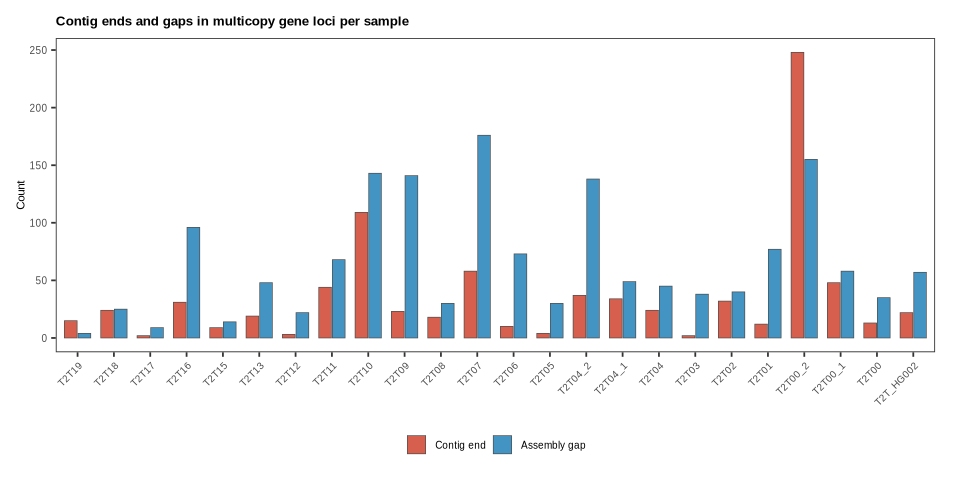

In [6]:
# Per-sample counts (reuse dt_ce / dt_gap from cell above)
dt_per_sample <- bind_rows(dt_ce, dt_gap) |>
    count(sample, feature) |>
    mutate(
        feature = factor(feature, levels = c("Contig end", "Assembly gap")),
        sample  = factor(sample, levels = rev(sort(unique(sample))))
    )

p_per_sample <- dt_per_sample |>
    ggplot(aes(x = sample, y = n, fill = feature)) +
    geom_col(position = position_dodge(width = 0.75), width = 0.7,
             colour = "grey30", linewidth = 0.2) +
    scale_fill_manual(values = c("Contig end" = "#d6604d", "Assembly gap" = "#4393c3")) +
    labs(x = NULL, y = "Count", fill = NULL,
         title = "Contig ends and gaps in multicopy gene loci per sample") +
    t2t_theme(base_size = 11) +
    theme(axis.text.x  = element_text(angle = 45, hjust = 1),
          legend.position = "bottom")

ggsave("../../doc/figures/multicopy_gene_per_sample.pdf", p_per_sample, width = 8, height = 4)
ggsave("../../doc/figures/multicopy_gene_per_sample.png", p_per_sample, width = 8, height = 4, dpi = 300)

options(repr.plot.width = 8, repr.plot.height = 4)
p_per_sample


In [ ]:
# Contig end distance summary table 
ce_all <- list.files(
    "../../analysis_other/multicopy_genes",
    pattern   = "contig_ends_to_multicopy_gene_distance\\.tsv$",
    recursive = TRUE, full.names = TRUE
) |>
  setNames(basename(dirname(list.files(
    "../../analysis_other/multicopy_genes",
    pattern   = "contig_ends_to_multicopy_gene_distance\\.tsv$",
    recursive = TRUE
  )))) |>
  imap_dfr(~ read_tsv(.x, show_col_types = FALSE) |> mutate(sample = .y)) |>
  filter(haplotype != "unassigned")

ce_summary <- ce_all |>
  group_by(sample) |>
  summarise(
    n_ends         = n(),
    n_overlap      = sum(distance == 0),
    n_1kb          = sum(distance <= 1e3),
    n_10kb         = sum(distance <= 10e3),
    n_50kb         = sum(distance <= 50e3),
    pct_overlap    = round(100 * n_overlap / n_ends, 1),
    pct_10kb       = round(100 * n_10kb    / n_ends, 1),
    median_dist_kb = round(median(distance) / 1e3, 1),
    .groups = "drop"
  ) |>
  arrange(sample)

ce_totals <- ce_summary |>
  summarise(
    sample         = "TOTAL",
    n_ends         = sum(n_ends),
    n_overlap      = sum(n_overlap),
    n_1kb          = sum(n_1kb),
    n_10kb         = sum(n_10kb),
    n_50kb         = sum(n_50kb),
    pct_overlap    = round(100 * sum(n_overlap) / sum(n_ends), 1),
    pct_10kb       = round(100 * sum(n_10kb)    / sum(n_ends), 1),
    median_dist_kb = round(median(ce_all$distance) / 1e3, 1)
  )

bind_rows(ce_summary, ce_totals) |> print(n = Inf)

write_tsv(ce_summary, "../../doc/tables/contig_end_multicopy_distance_summary.tsv")

#  Key numbers 
cat(sprintf(
  "\nAcross all %d samples (%d haplotype-resolved contig ends):\n  %.1f%% overlap a multicopy gene locus (distance = 0)\n  %.1f%% within 10 kb\n  Median distance: %.1f kb\n",
  nrow(ce_summary),
  ce_totals$n_ends,
  ce_totals$pct_overlap,
  ce_totals$pct_10kb,
  ce_totals$median_dist_kb
))

# A tibble: 25 × 9
   sample    n_ends n_overlap n_1kb n_10kb n_50kb pct_overlap pct_10kb
   <chr>      <int>     <int> <int>  <int>  <int>       <dbl>    <dbl>
 1 T2T00        116        18    26     42     53        15.5     36.2
 2 T2T00_1      264        62    77    126    163        23.5     47.7
 3 T2T00_2     1423       379   433    630    807        26.6     44.3
 4 T2T01        152        22    33     73     93        14.5     48  
 5 T2T02        358        57    69    115    144        15.9     32.1
 6 T2T03         46         4     9     21     31         8.7     45.7
 7 T2T04        124        28    34     56     64        22.6     45.2
 8 T2T04_1      292        48    58    104    130        16.4     35.6
 9 T2T04_2      372        68    82    148    196        18.3     39.8
10 T2T05         78         6     9     24     28         7.7     30.8
11 T2T06        116        24    29     44     52        20.7     37.9
12 T2T07        343        89    97    157    187        2

### 2a-ii) Random-expectation baseline for multicopy-gene proximity

How many contig ends would be expected within 10 kb of a multicopy gene locus by chance alone, to compare against the observed 41%? Two estimates: an analytical genome-coverage baseline, and an empirical `bedtools shuffle` permutation null.

In [ ]:
# ── Random-expectation baseline: genome coverage of "near a multicopy gene" ────
# Null model: if contig ends were scattered uniformly across CHM13, what
# fraction would we expect to land within 10 kb of an annotated multicopy
# gene locus purely from genome coverage (no shuffling needed - just the
# fraction of the genome that lies in that neighbourhood)?

chm13_fai     <- "../../data/ref/T2T-CHM13.v2.fasta.fai"
multicopy_bed <- "../../analysis_other/multicopy_genes/chm13_multicopy_genes.bed"

fai_tbl <- read_tsv(chm13_fai, col_names = c("chrom", "length", "x1", "x2", "x3"),
                     col_types = "cinnn", show_col_types = FALSE)
genome_len <- sum(fai_tbl$length)

genome_file <- tempfile(fileext = ".genome")
fai_tbl |> select(chrom, length) |> write_tsv(genome_file, col_names = FALSE)

mcg_10kb_bp <- system(
  sprintf("sort -k1,1 -k2,2n %s | bedtools slop -i - -g %s -b 10000 | bedtools merge -i - | awk '{s+=$3-$2} END{print s}'",
          multicopy_bed, genome_file),
  intern = TRUE
) |> as.numeric()

baseline_pct_10kb <- 100 * mcg_10kb_bp / genome_len

cat(sprintf(
  "Random-expectation baseline (genome coverage): %.1f%% of the CHM13 genome (%.0f / %.0f Mb) lies within 10 kb of an annotated multicopy gene locus.\nObserved contig-end rate: %.1f%%  ->  %.2fx enrichment over chance.\n",
  baseline_pct_10kb, mcg_10kb_bp / 1e6, genome_len / 1e6,
  ce_totals$pct_10kb, ce_totals$pct_10kb / baseline_pct_10kb
))


In [ ]:
# ── Empirical baseline: bedtools shuffle permutation ────────────────────────
# Shuffle the observed contig-end positions across the CHM13 genome
# (bedtools shuffle, no two shuffled ends allowed to overlap) and recompute
# the fraction within 10 kb of a multicopy gene locus each time. Repeating
# this gives an empirical null distribution / p-value for the observed 41%,
# without the coverage-based approximation used above.
# Reuses genome_file / multicopy_bed / ce_all from the cells above.

obs_bed <- tempfile(fileext = ".bed")
ce_all |>
  transmute(chrom, start = end_start, end = end_end) |>
  write_tsv(obs_bed, col_names = FALSE)

n_shuffles <- 200

shuffle_pct_10kb <- function(seed) {
  cmd <- sprintf(
    "bedtools shuffle -i %s -g %s -seed %d -noOverlapping 2>/dev/null | sort -k1,1 -k2,2n | bedtools closest -d -a - -b %s",
    obs_bed, genome_file, seed, multicopy_bed
  )
  dist <- system(cmd, intern = TRUE) |>
    str_split("\t") |>
    map_chr(~ tail(.x, 1)) |>
    as.numeric()
  100 * mean(dist <= 10000, na.rm = TRUE)
}

set.seed(42)
null_pct_10kb <- map_dbl(seq_len(n_shuffles), shuffle_pct_10kb)

p_val <- (sum(null_pct_10kb >= ce_totals$pct_10kb) + 1) / (n_shuffles + 1)

cat(sprintf(
  "Empirical null (bedtools shuffle, n=%d): mean = %.1f%%, 95%% range = [%.1f%%, %.1f%%]\nObserved: %.1f%%\nEmpirical p-value (null >= observed): %.4g\n",
  n_shuffles, mean(null_pct_10kb),
  quantile(null_pct_10kb, .025), quantile(null_pct_10kb, .975),
  ce_totals$pct_10kb, p_val
))

p_null <- tibble(pct_within_10kb = null_pct_10kb) |>
  ggplot(aes(x = pct_within_10kb)) +
  geom_histogram(bins = 30, fill = "grey75", colour = "grey30", linewidth = 0.2) +
  geom_vline(xintercept = ce_totals$pct_10kb, colour = "#d6604d", linewidth = 1) +
  annotate("text", x = ce_totals$pct_10kb, y = Inf,
           label = sprintf("Observed: %.1f%%", ce_totals$pct_10kb),
           colour = "#d6604d", vjust = 1.5, hjust = -0.05, size = 3.5) +
  labs(x = "% of shuffled contig ends within 10 kb of a multicopy gene locus",
       y = "Shuffles",
       title = sprintf("Random-expectation baseline (n=%d bedtools shuffles)", n_shuffles)) +
  t2t_theme(base_size = 11)

ggsave("../../doc/figures/multicopy_gene_contig_end_null_distribution.pdf", p_null, width = 6, height = 4)
ggsave("../../doc/figures/multicopy_gene_contig_end_null_distribution.png", p_null, width = 6, height = 4, dpi = 300)

options(repr.plot.width = 6, repr.plot.height = 4)
p_null


In [ ]:
# Gap distance summary table 
gap_all <- list.files(
    "../../analysis_other/multicopy_genes",
    pattern   = "gap_to_multicopy_gene_distance\\.tsv$",
    recursive = TRUE, full.names = TRUE
) |>
  setNames(basename(dirname(list.files(
    "../../analysis_other/multicopy_genes",
    pattern   = "gap_to_multicopy_gene_distance\\.tsv$",
    recursive = TRUE
  )))) |>
  imap_dfr(~ read_tsv(.x, show_col_types = FALSE) |> mutate(sample = .y))

gap_summary <- gap_all |>
  group_by(sample) |>
  summarise(
    n_gaps         = n(),
    n_overlap      = sum(distance == 0),
    n_1kb          = sum(distance <= 1e3),
    n_10kb         = sum(distance <= 10e3),
    n_50kb         = sum(distance <= 50e3),
    pct_overlap    = round(100 * n_overlap / n_gaps, 1),
    pct_10kb       = round(100 * n_10kb    / n_gaps, 1),
    median_dist_kb = round(median(distance) / 1e3, 1),
    .groups = "drop"
  ) |>
  arrange(sample)

gap_totals <- gap_summary |>
  summarise(
    sample         = "TOTAL",
    n_gaps         = sum(n_gaps),
    n_overlap      = sum(n_overlap),
    n_1kb          = sum(n_1kb),
    n_10kb         = sum(n_10kb),
    n_50kb         = sum(n_50kb),
    pct_overlap    = round(100 * sum(n_overlap) / sum(n_gaps), 1),
    pct_10kb       = round(100 * sum(n_10kb)    / sum(n_gaps), 1),
    median_dist_kb = round(median(gap_all$distance) / 1e3, 1)
  )

bind_rows(gap_summary, gap_totals) |> print(n = Inf)

write_tsv(gap_summary, "../../doc/tables/gap_multicopy_distance_summary.tsv")

cat(sprintf(
  "\nAcross all %d samples (%d gaps):\n  %.1f%% overlap a multicopy gene locus (distance = 0)\n  %.1f%% within 10 kb\n  Median distance: %.1f kb\n",
  nrow(gap_summary),
  gap_totals$n_gaps,
  gap_totals$pct_overlap,
  gap_totals$pct_10kb,
  gap_totals$median_dist_kb
))


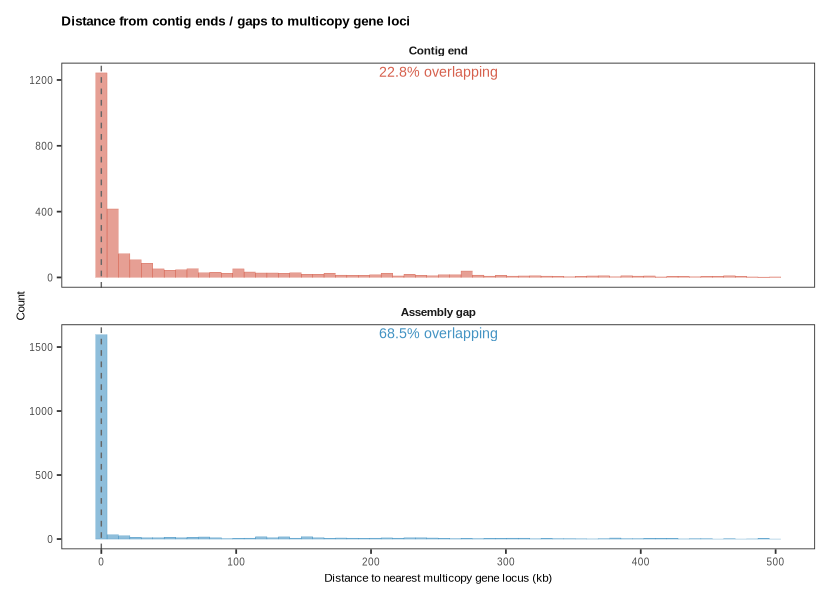

In [7]:
# Load full distance distributions (all distances, not just 0)
dt_dist_ce <- read_tsv(ce_files, show_col_types = FALSE) %>%
  filter(haplotype != "unassigned") %>%
  transmute(distance, feature = "Contig end")

dt_dist_gap <- read_tsv(gap_files, show_col_types = FALSE) %>%
  transmute(distance, feature = "Assembly gap")

dt_dist <- bind_rows(dt_dist_ce, dt_dist_gap) |>
    mutate(
        feature  = factor(feature, levels = c("Contig end", "Assembly gap")),
        dist_kb  = distance / 1000
    )

# Fraction overlapping (distance == 0)
frac_labels <- dt_dist |>
    group_by(feature) |>
    summarise(
        pct_overlap = 100 * mean(distance == 0),
        label       = sprintf("%.1f%% overlapping", pct_overlap),
        .groups = "drop"
    )

p_dist <- dt_dist |>
    filter(dist_kb <= 500) |>   # cap at 500 kb for readability
    ggplot(aes(x = dist_kb, fill = feature, colour = feature)) +
    geom_histogram(bins = 60, alpha = 0.6, position = "identity", linewidth = 0.1) +
    geom_vline(xintercept = 0, linetype = "dashed", colour = "grey40", linewidth = 0.4) +
    geom_text(data = frac_labels,
              aes(label = label, colour = feature),
              x = 250, y = Inf, vjust = 1.4, hjust = 0.5,
              size = 3, show.legend = FALSE,
              position = position_nudge(y = 0)) +
    facet_wrap(~ feature, ncol = 1, scales = "free_y") +
    scale_fill_manual(values   = c("Contig end" = "#d6604d", "Assembly gap" = "#4393c3")) +
    scale_colour_manual(values = c("Contig end" = "#d6604d", "Assembly gap" = "#4393c3")) +
    scale_x_continuous(labels = scales::comma) +
    labs(x = "Distance to nearest multicopy gene locus (kb)",
         y = "Count", fill = NULL, colour = NULL,
         title = "Distance from contig ends / gaps to multicopy gene loci") +
    t2t_theme(base_size = 11) +
    theme(legend.position = "none",
          strip.text = element_text(face = "bold"))

ggsave("../../doc/figures/multicopy_gene_distance_hist.pdf", p_dist, width = 7, height = 5)
ggsave("../../doc/figures/multicopy_gene_distance_hist.png", p_dist, width = 7, height = 5, dpi = 300)

options(repr.plot.width = 7, repr.plot.height = 5)
p_dist


### 2b) Small contig satellite classification

For each contig ≥10 kb and <10 Mb, the Snakemake rule `small_contig_satellite_class` (qc_extended.smk) intersects the aligned reference span with the CHM13v2.0 CenSat annotation. Contigs where ≥50% of aligned bases fall in satellite/pericentromeric sequence are labelled **satellite**; the rest **non_satellite**. The reviewer asks for the non-satellite count specifically, since satellite small contigs are expected artefacts of assembling repetitive centromeric arrays.

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Sat — Haplotype 1' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Sat — Haplotype 2' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Sat — Unassigned' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Non-sat — Haplotype 1' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Non-sat — Haplotype 2' in 'mbcsToSbcs': - substituted for — (U+2014)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Non-sat — Unassigned' in 'mbcsToSbcs': - substituted for — (U+2014)”


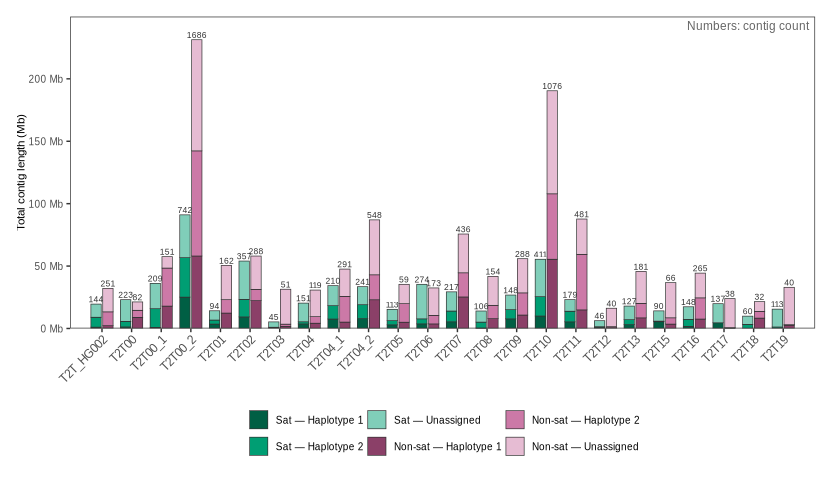

In [26]:
# ── Small contig satellite classification ─────────────────────────────────────
sc <- read_tsv(
  "../../doc/tables/for_plots/small_contig_satellite_class.all_samples.tsv",
  show_col_types = FALSE
) |>
  mutate(
    haplotype      = factor(haplotype,
                            levels = c("haplotype1", "haplotype2", "unassigned"),
                            labels = c("Haplotype 1", "Haplotype 2", "Unassigned")),
    classification = factor(classification,
                            levels = c("satellite", "non_satellite"),
                            labels = c("Satellite", "Non-satellite")),
    sample         = factor(sample, levels = sort(unique(sample)))
  )

# Hue encodes classification (Okabe-Ito green / reddish-purple, CB-safe, distinct from haplotype orange/blue)
# Darkness encodes haplotype assignment (dark = hap1, medium = hap2, light = unassigned)
sat_cols  <- c(`Haplotype 1` = "#005f44", `Haplotype 2` = "#009E73", Unassigned = "#80ceb9")
nsat_cols <- c(`Haplotype 1` = "#8b4068", `Haplotype 2` = "#CC79A7", Unassigned = "#e6bcd3")

fill_vals <- c(
  setNames(sat_cols,  paste(names(sat_cols),  "Satellite",     sep = ".")),
  setNames(nsat_cols, paste(names(nsat_cols), "Non-satellite", sep = "."))
)

# Per sample × haplotype × classification: total bp (length-weighted)
sc_counts <- sc |>
  group_by(sample, haplotype, classification) |>
  summarise(total_mb = sum(contig_length_bp) / 1e6, .groups = "drop") |>
  mutate(
    fill_id  = paste(haplotype, classification, sep = "."),
    samp_num = as.integer(sample),
    x_pos    = samp_num + if_else(classification == "Satellite", -0.2, 0.2)
  )

# Bar-top labels: total contig count per sample × classification
sc_labels <- sc |>
  count(sample, classification) |>
  mutate(
    samp_num = as.integer(sample),
    x_pos    = samp_num + if_else(classification == "Satellite", -0.2, 0.2)
  ) |>
  left_join(
    sc_counts |>
      group_by(sample, classification) |>
      summarise(total_mb = sum(total_mb), .groups = "drop"),
    by = c("sample", "classification")
  )

n_samp <- nlevels(sc$sample)

fill_breaks <- c(paste(names(sat_cols),  "Satellite",     sep = "."),
                 paste(names(nsat_cols), "Non-satellite", sep = "."))
fill_labels <- c(paste("Sat —",  names(sat_cols)),
                 paste("Non-sat —", names(nsat_cols)))

p_sc_count <- ggplot(sc_counts,
    aes(x     = x_pos,
        y     = total_mb,
        fill  = fill_id,
        group = interaction(sample, classification))) +
  geom_col(position = "stack", width = 0.35, colour = "grey20", linewidth = 0.2) +
  geom_text(
    data    = sc_labels,
    mapping = aes(x = x_pos, y = total_mb, label = n, group = NULL, fill = NULL),
    vjust   = -0.3, size = 1.8, colour = "grey20", inherit.aes = FALSE
  ) +
  scale_fill_manual(
    values = fill_vals,
    breaks = fill_breaks,
    labels = fill_labels,
    name   = NULL
  ) +
  scale_x_continuous(
    breaks = seq_len(n_samp),
    labels = levels(sc$sample),
    expand = expansion(add = 0.7)
  ) +
  scale_y_continuous(
    labels = scales::label_number(suffix = " Mb", accuracy = 1),
    expand = expansion(mult = c(0, 0.08))
  ) +
  labs(x = NULL, y = "Total contig length (Mb)") +
  annotate("text", x = Inf, y = Inf, label = "Numbers: contig count",
           hjust = 1.05, vjust = 1.5, size = 2.5, colour = "grey40") +
  t2t_theme(base_size = 9) +
  theme(
    axis.text.x     = element_text(angle = 45, hjust = 1, size = 7),
    legend.position = "bottom"
  )

ggsave("../../doc/figures/small_contig_sat_class_count.pdf", p_sc_count, width = 7, height = 4)
ggsave("../../doc/figures/small_contig_sat_class_count.png", p_sc_count, width = 7, height = 4, dpi = 300)

options(repr.plot.width = 7, repr.plot.height = 4)
p_sc_count

In [ ]:
# Non-satellite small contig summary (for rebuttal text) 
# Cross-tabulate haplotype × classification to get resolved counts separately
sc_xtab <- sc |>
  count(sample, haplotype, classification) |>
  pivot_wider(names_from = c(haplotype, classification),
              values_from = n, values_fill = 0)

sc_resolved <- sc |>
  filter(haplotype != "Unassigned") |>
  group_by(sample) |>
  summarise(
    n_resolved_sat     = sum(classification == "Satellite"),
    n_resolved_nonsat  = sum(classification == "Non-satellite"),
    n_resolved_total   = n(),
    mb_resolved_nonsat = round(sum(contig_length_bp[classification == "Non-satellite"]) / 1e6, 2),
    .groups = "drop"
  ) |>
  mutate(frac_nonsat = round(n_resolved_nonsat / n_resolved_total, 3)) |>
  arrange(sample)

print(sc_resolved, n = Inf)

cat(sprintf(
  "\nAcross %d samples:\n  Non-satellite (resolved): mean %.0f, median %.0f, range %d–%d, total %d\n  Satellite (resolved):     mean %.0f, median %.0f, range %d–%d, total %d\n  Fraction non-satellite of resolved: %.1f%%\n",
  nrow(sc_resolved),
  mean(sc_resolved$n_resolved_nonsat),
  median(sc_resolved$n_resolved_nonsat),
  min(sc_resolved$n_resolved_nonsat),
  max(sc_resolved$n_resolved_nonsat),
  sum(sc_resolved$n_resolved_nonsat),
  mean(sc_resolved$n_resolved_sat),
  median(sc_resolved$n_resolved_sat),
  min(sc_resolved$n_resolved_sat),
  max(sc_resolved$n_resolved_sat),
  sum(sc_resolved$n_resolved_sat),
  100 * sum(sc_resolved$n_resolved_nonsat) / sum(sc_resolved$n_resolved_total)
))


# A tibble: 24 × 6
   sample   n_resolved_sat n_resolved_nonsat n_resolved_total mb_resolved_nonsat
   <fct>             <int>             <int>            <int>              <dbl>
 1 T2T_HG0…             37                65              102              13.3 
 2 T2T00                28                14               42              14.5 
 3 T2T00_1              46                72              118              48.4 
 4 T2T00_2             239               378              617             142.  
 5 T2T01                14                39               53              23.1 
 6 T2T02                85                47              132              31.3 
 7 T2T03                 7                11               18               3.44
 8 T2T04                18                32               50               9.5 
 9 T2T04_1              67                56              123              25.6 
10 T2T04_2              65                91              156              43   
11 T2T05 

In [36]:
# Summary table (contig counts + bp totals)
sc_summary <- sc |>
  group_by(sample) |>
  summarise(
    n_satellite        = sum(classification == "Satellite"),
    n_non_satellite    = sum(classification == "Non-satellite"),
    n_unassigned       = sum(haplotype == "Unassigned"),
    n_total            = n(),
    mb_satellite       = round(sum(contig_length_bp[classification == "Satellite"])    / 1e6, 2),
    mb_non_satellite   = round(sum(contig_length_bp[classification == "Non-satellite"]) / 1e6, 2),
    median_length_kb   = round(median(contig_length_bp) / 1e3, 1),
    frac_satellite     = round(n_satellite  / n_total, 3),
    frac_unassigned    = round(n_unassigned / n_total, 3),
    .groups            = "drop"
  ) |>
  arrange(sample)

write_tsv(sc_summary, "../../doc/tables/small_contig_sat_summary.tsv")
print(sc_summary, n = Inf)


# A tibble: 24 × 10
   sample    n_satellite n_non_satellite n_unassigned n_total mb_satellite
   <fct>           <int>           <int>        <int>   <int>        <dbl>
 1 T2T_HG002         144             251          293     395        19.5 
 2 T2T00             223              82          263     305        23.1 
 3 T2T00_1           209             151          242     360        36.1 
 4 T2T00_2           742            1686         1811    2428        91.0 
 5 T2T01              94             162          203     256        14.2 
 6 T2T02             357             288          513     645        54   
 7 T2T03              45              51           78      96         5.27
 8 T2T04             151             119          220     270        20.3 
 9 T2T04_1           210             291          378     501        34.4 
10 T2T04_2           241             548          633     789        33.5 
11 T2T05             113              59          144     172        15.3 
12 T2

## 2) Karyogram: Genomic distribution of assembly issues

Combined karyogram showing the reference-coordinate density of:
- **Errors & Misjoins** — Flagger `Err` + Nucflag `MISJOIN`
- **Collapses** — Flagger `Col` + Nucflag `COLLAPSE*`
- **Duplications** — Flagger `Dup`
- **Assembly Gaps** — `N_region` from gap analysis
- **Contig Ends** — positions where contigs terminate (all samples)
- **Mendelian Errors** — MIV sites (T2T00 and T2T04 trio samples only)

Each panel is independently scaled to its own maximum (0–1), so colours reflect within-panel relative density.

In [8]:
suppressPackageStartupMessages(library(ggideogram))

# 1. existing assembly issues (Flagger + Nucflag + GapAnalysis)
dt_issues_raw <- read_tsv(
    "../../doc/tables/for_plots/assembly_issues_all_samples.tsv",
    show_col_types = FALSE
)

dt_issues <- dt_issues_raw %>%
    mutate(feature_type = str_remove(feature_type, "_windowed$")) %>%
    mutate(feature_group = case_when(
        str_detect(feature_type, regex("^Err$|^MISJOIN$", ignore_case = TRUE)) ~ "Errors & Misjoins",
        str_detect(feature_type, regex("COLLAPSE|^Col$",  ignore_case = TRUE)) ~ "Collapses",
        feature_type == "Dup"      ~ "Duplications",
        feature_type == "N_region" ~ "Assembly Gaps",
        TRUE ~ NA_character_
    )) %>%
    filter(!is.na(feature_group)) %>%
    select(sample, chr, start, end, feature_group)

# 2. Mendelian Inheritance Violation sites (T2T00, T2T04)
miv_files <- list.files(
    "../../analysis_other/mendelian_qc",
    pattern  = "merr\\.bed\\.gz$",
    recursive = TRUE, full.names = TRUE
)
dt_miv <- read_tsv(miv_files,
    col_names = c("chr", "start", "end", "change", "count"),
    col_types = "ciicc", id = "path", show_col_types = FALSE) %>%
  transmute(sample = basename(dirname(path)), chr, start, end,
            feature_group = "Mendelian Errors")

# 3. contig ends (all samples, lifted to reference coordinates)
contig_end_files <- list.files(
    "../../analysis_other/multicopy_genes",
    pattern  = "contig_ends\\.bed$",
    recursive = TRUE, full.names = TRUE
)
dt_contig_ends <- read_tsv(contig_end_files,
    col_names = c("chr", "start", "end", "contig", "length", "haplotype", "side"),
    col_types = "ciicicc", id = "path", show_col_types = FALSE) %>%
  filter(haplotype != "unassigned") %>%
  transmute(sample = basename(dirname(path)), chr, start, end,
            feature_group = "Contig Ends")

# 4. combine
dt_all <- bind_rows(dt_issues, dt_miv, dt_contig_ends)
cat("Rows per feature group:\n")
print(count(dt_all, feature_group))


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


Rows per feature group:
# A tibble: 6 × 2
  feature_group          n
  <chr>              <int>
1 Assembly Gaps       1076
2 Collapses          47645
3 Contig Ends         3592
4 Duplications       20561
5 Errors & Misjoins  31318
6 Mendelian Errors  227830


In [9]:
panel_order <- c(
    "Errors & Misjoins",
    "Collapses",
    "Duplications",
    "Assembly Gaps",
    "Contig Ends",
    "Mendelian Errors"
)

bin_size <- 2e6  # 2 Mb bins (same as figure 1 karyogram)

# Chromosome arm boundaries (p / q) from cytoband — used by geom_ideogram
arm_boundaries <- cytoband %>%
    group_by(chr, arm) %>%
    summarise(arm_start = min(start), arm_end = max(end), .groups = "drop")

# Bin counts per feature group, assign arm, scale within each panel
heatmap_data <- dt_all %>%
    filter(str_detect(chr, "^chr[0-9XY]+$")) %>%
    left_join(
        karyotype_chm13 %>% mutate(chr = as.character(chr)) %>% select(chr, chr_length = end),
        by = "chr"
    ) %>%
    filter(!is.na(chr_length)) %>%
    mutate(
        bin_start = pmax(1, floor(start / bin_size) * bin_size + 1),
        bin_end   = pmin(bin_start + bin_size - 1, chr_length)
    ) %>%
    group_by(feature_group, chr, bin_start, bin_end) %>%
    summarise(n = n(), .groups = "drop") %>%
    group_by(feature_group) %>%
    mutate(scaled_intensity = n / max(n)) %>%
    ungroup() %>%
    # Assign p/q arm to each bin via its midpoint
    mutate(bin_mid = (bin_start + bin_end) / 2) %>%
    left_join(arm_boundaries, by = "chr", relationship = "many-to-many") %>%
    filter(bin_mid >= arm_start & bin_mid <= arm_end) %>%
    select(-bin_mid, -arm_start, -arm_end) %>%
    mutate(
        chr           = factor(chr, levels = levels(karyotype_chm13$chr)),
        feature_group = factor(feature_group, levels = panel_order)
    )

# Chromosome outlines (one row per arm × panel)
karyotype_bg <- crossing(
    arm_boundaries %>% rename(start = arm_start, end = arm_end),
    feature_group = factor(panel_order, levels = panel_order)
) %>%
    mutate(chr = factor(chr, levels = levels(karyotype_chm13$chr)))

cat(sprintf("Heatmap bins: %d across %d panels\n", nrow(heatmap_data), length(panel_order)))

Heatmap bins: 6890 across 6 panels


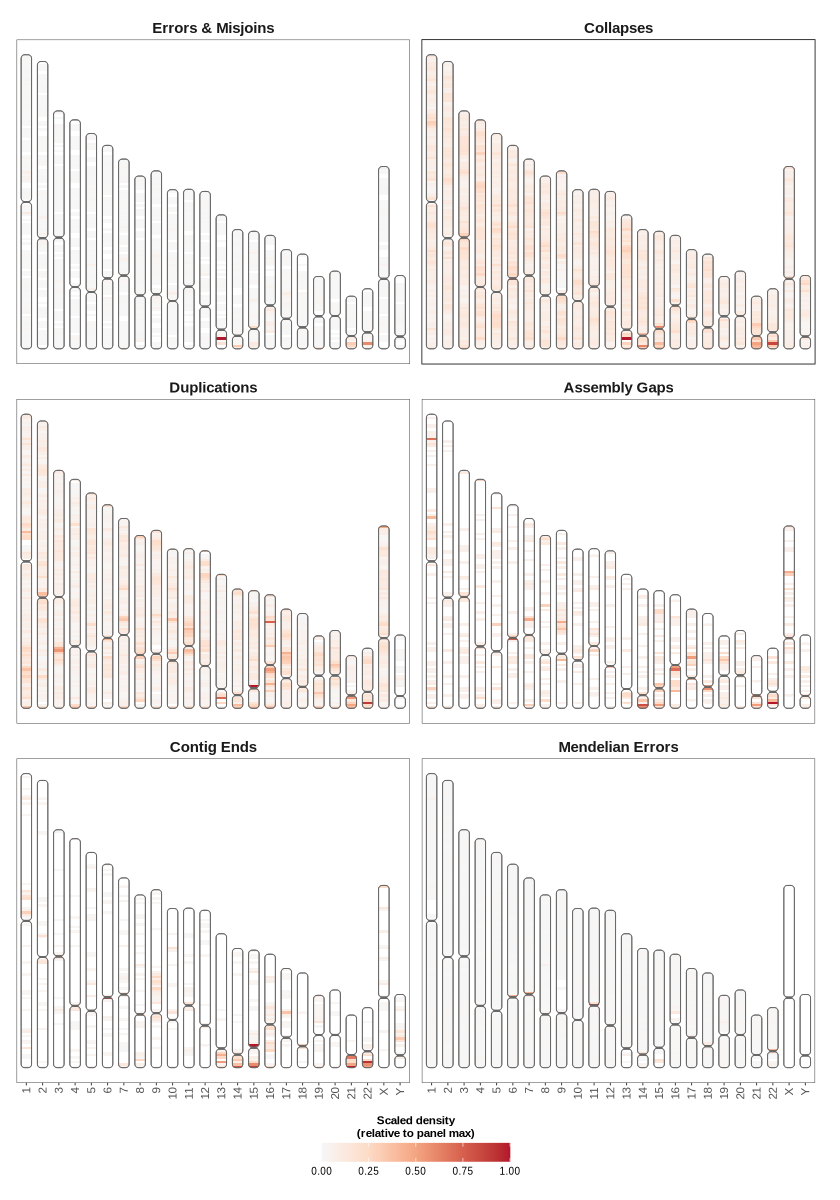

In [10]:
fig_karyogram_issues <- ggplot() +
    # Heatmap fill (per-panel scaled density)
    geom_ideogram(
        data = heatmap_data,
        aes(x = chr, ymin = bin_start, ymax = bin_end,
            chrom = chr, arm = arm, fill = scaled_intensity),
        width = 0.7, radius = unit(2.5, "pt"), colour = NA
    ) +
    scale_fill_gradientn(
        colours  = c("#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b"),
        values   = scales::rescale(c(0, 0.25, 0.5, 0.75, 1)),
        name     = "Scaled density\n(relative to panel max)",
        limits   = c(0, 1),
        na.value = "transparent",
        guide    = guide_colorbar(
            title.position = "top", title.hjust = 0.5,
            barwidth = unit(4, "cm"), barheight = unit(0.4, "cm")
        )
    ) +
    # Chromosome outlines
    geom_ideogram(
        data = karyotype_bg,
        aes(x = chr, ymin = start, ymax = end, chrom = chr, arm = arm),
        fill = NA, colour = "grey40", width = 0.7,
        radius = unit(2.5, "pt"), linewidth = 0.5, show.legend = FALSE
    ) +
    facet_wrap(~ feature_group, ncol = 2) +
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    theme(
        axis.title   = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.text.x  = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 7),
        panel.grid   = element_blank(),
        strip.text   = element_text(face = "bold", size = 9),
        legend.position = "bottom"
    )

ggsave("../../doc/figures/fig_karyogram_issues.pdf", fig_karyogram_issues, width = 7, height = 10)
ggsave("../../doc/figures/fig_karyogram_issues.png", fig_karyogram_issues, width = 7, height = 10, dpi = 300)

options(repr.plot.width = 7, repr.plot.height = 10)
fig_karyogram_issues

## 3) Classification of HG002 assembly errors

Assembly errors reported by QGC

In [11]:
# Read error classification
dt_gqc <- read_tsv(
    "../../analysis_other/GQC/T2T_HG002/gqc_error_classification/summary.tsv",
    show_col_types = FALSE
)

cat_order <- c(
    "Non-repetitive", "Coding (CDS)",
    "Homopolymers", "Tandem repeats", "Satellite repeats",
    "Segmental duplications", "Highly polymorphic (MHC/KIR/VDJ)"
)

dt_gqc

category,variant_type,n_bases_covered,n_errors_total,pct_of_total,n_errors_consensus,n_errors_phasing,QV_all,QV_consensus
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
All regions,All,5941170857,502363,100.00,422532,79831,40.73,41.48
All regions,Indel,5941170857,489134,97.37,410155,78979,40.84,41.61
All regions,SNV,5941170857,13229,2.63,12377,852,56.52,56.81
Non-repetitive,All,4831696422,781,0.16,382,399,67.91,71.02
Non-repetitive,Indel,4831696422,396,0.08,215,181,70.86,73.52
Non-repetitive,SNV,4831696422,385,0.08,167,218,70.99,74.61
Coding (CDS),All,70310437,56,0.01,38,18,60.99,62.67
Coding (CDS),Indel,70310437,41,0.01,34,7,62.34,63.16
Coding (CDS),SNV,70310437,15,0.00,4,11,66.71,72.45


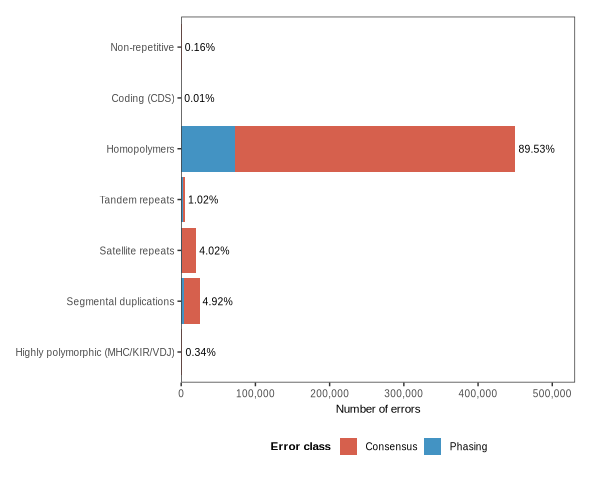

In [12]:
#  error distribution by category
p_counts <- dt_gqc |>
    filter(category != "All regions", variant_type == "All") |>
    mutate(category = factor(category, levels = rev(cat_order))) |>
    select(category, pct_of_total, n_errors_consensus, n_errors_phasing, n_errors_total) |>
    pivot_longer(c(n_errors_consensus, n_errors_phasing),
                 names_to = "error_class", values_to = "n") |>
    mutate(error_class = recode(error_class,
        n_errors_consensus = "Consensus",
        n_errors_phasing   = "Phasing"
    )) |>
    ggplot(aes(y = category, x = n, fill = error_class)) +
    geom_col() +
    geom_text(
        data = dt_gqc |>
            filter(category != "All regions", variant_type == "All") |>
            mutate(category = factor(category, levels = rev(cat_order))),
        aes(y = category, x = n_errors_total,
            label = paste0(pct_of_total, "%")),
        inherit.aes = FALSE, hjust = -0.1, size = 2.2
    ) +
    scale_x_continuous(
        labels = scales::comma,
        expand = expansion(mult = c(0, 0.18))
    ) +
    scale_fill_manual(values = c(Consensus = "#d6604d", Phasing = "#4393c3")) +
    labs(x = "Number of errors", y = NULL, fill = "Error class") +
    t2t_theme(base_size = 9) +
    theme(legend.position = "bottom")

ggsave("../../doc/figures/fig_gqc_error_counts.pdf",  p_counts, width = 5, height = 4)
ggsave("../../doc/figures/fig_gqc_error_counts.png",  p_counts, width = 5, height = 4, dpi = 300)

options(repr.plot.width = 5, repr.plot.height = 4)
p_counts


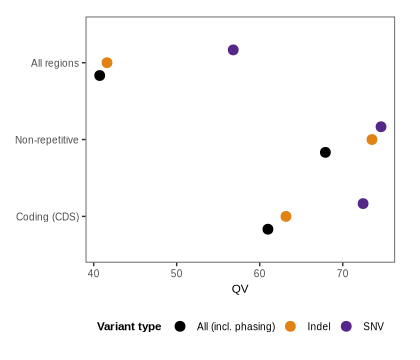

In [13]:
# QV for avaluable categories only
p_qv <- dt_gqc |>
    filter(
        category %in% c("All regions", "Non-repetitive", "Coding (CDS)"),
        !is.na(QV_consensus)
    ) |>
    mutate(
        category     = factor(category, levels = rev(c("All regions", "Non-repetitive", "Coding (CDS)"))),
        variant_type = factor(variant_type, levels = c("All", "Indel", "SNV")),
        QV_plot      = if_else(variant_type == "All", QV_all, QV_consensus)
    ) |>
    ggplot(aes(x = QV_plot, y = category, colour = variant_type)) +
    geom_point(size = 2.5, position = position_dodge(0.5)) +
    scale_colour_manual(
        values = c(All = "black", Indel = "#e08214", SNV = "#542788"),
        labels = c(All = "All (incl. phasing)", Indel = "Indel", SNV = "SNV")
    ) +
    labs(x = "QV", y = NULL, colour = "Variant type") +
    t2t_theme(base_size = 9) +
    theme(legend.position = "bottom")

ggsave("../../doc/figures/fig_gqc_qv.pdf", p_qv, width = 3.5, height = 3)
ggsave("../../doc/figures/fig_gqc_qv.png", p_qv, width = 3.5, height = 3, dpi = 300)

options(repr.plot.width = 3.5, repr.plot.height = 3)
p_qv

## 4) Parent-of-Origin Detection Summary

Per-chromosome PofO assignment status across all 20 samples:
- **Correct**: PatMat confirmed HP1 was already maternal (no swap needed)
- **Flipped**: HP1 was paternal — contigs reassigned to hap2
- **Unassigned**: insufficient iDMR evidence for a call
- **Sex chrom**: chrX/chrY in male samples (assigned by biological rule)

In [14]:
samples_pofo <- c(
    "T2T00", "T2T01", "T2T02", "T2T03", "T2T04", "T2T05",
    "T2T06", "T2T07", "T2T08", "T2T09", "T2T10", "T2T11",
    "T2T12", "T2T13", "T2T15", "T2T16", "T2T17", "T2T18",
    "T2T19", "T2T_HG002"
)

# PofO scores — autosomes + chrX where PatMat succeeded
dt_scores <- tibble(sample = samples_pofo) %>%
  mutate(path = paste0("../../analysis_other/parent_of_origin/", sample, "/", sample, "_PofO_Scores.tsv")) %>%
  rowwise() %>%
  mutate(data = list(read_tsv(path, show_col_types = FALSE) %>%
                     transmute(chr = Chromosome, Origin_HP1, score = PofO_Assignment_Score))) %>%
  ungroup() %>%
  unnest(data) %>%
  select(sample, chr, Origin_HP1, score)

# sex: male if chrY contigs present in the assignment table
dt_sex <- tibble(sample = samples_pofo) %>%
  mutate(path = paste0("../../assembly/output/final/", sample, "/contig_pofo_assignment.tsv")) %>%
  rowwise() %>%
  mutate(is_male = any(read_tsv(path, show_col_types = FALSE)$mapped_chromosome == "chrY", na.rm = TRUE)) %>%
  ungroup() %>%
  select(sample, is_male)

chr_order <- c(paste0("chr", 1:22), "chrX", "chrY")

dt_autosomes_x <- expand_grid(sample = samples_pofo, chr = c(paste0("chr", 1:22), "chrX")) %>%
    left_join(dt_scores, by = c("sample", "chr")) %>%
    left_join(dt_sex,   by = "sample") %>%
    mutate(status = case_when(
        is_male & chr == "chrX" ~ "Sex chrom",
        Origin_HP1 == "Maternal" ~ "Correct",
        Origin_HP1 == "Paternal" ~ "Flipped",
        TRUE                     ~ "Unassigned"
    )) %>%
    select(sample, chr, status)

dt_y <- dt_sex %>%
    filter(is_male) %>%
    transmute(sample, chr = "chrY", status = "Sex chrom")

dt_chr_status <- bind_rows(dt_autosomes_x, dt_y) %>%
    mutate(
        chr    = factor(chr, levels = chr_order),
        sample = factor(sample, levels = rev(samples_pofo)),
        status = factor(status, levels = c("Correct", "Flipped", "Unassigned", "Sex chrom"))
    )


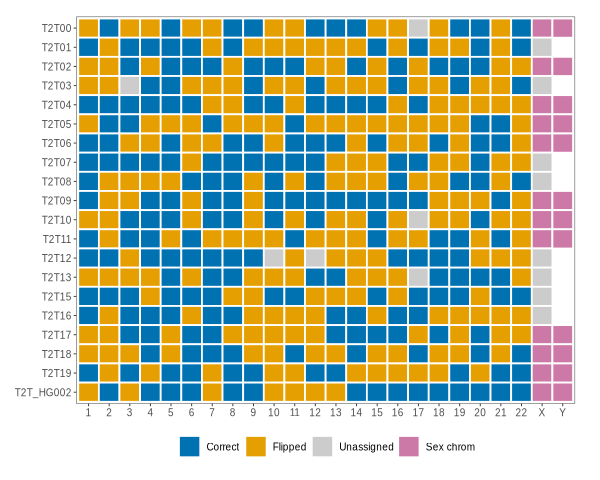

In [15]:
# Pofo Tile plot 
# Okabe-Ito colorblind-safe palette
# blue = confirmed OK, orange = needed correction, grey = no call, mauve = sex-determined
col_status <- c(
    "Correct"    = "#0072B2",  # blue
    "Flipped"    = "#E69F00",  # orange
    "Unassigned" = "#CCCCCC",  # light grey
    "Sex chrom"  = "#CC79A7"   # mauve
)

p_tile <- dt_chr_status %>%
    ggplot(aes(x = chr, y = sample, fill = status)) +
    geom_tile(colour = "white", linewidth = 0.5) +
    scale_fill_manual(values = col_status, na.value = "grey95", name = NULL, drop = FALSE) +
    scale_x_discrete(labels = function(x) gsub("chr", "", x)) +
    labs(x = NULL, y = NULL) +
    theme(
        legend.position = "bottom",
        legend.key.size = unit(0.5, "cm")
    )

ggsave("../../doc/figures/pofo_chr_assignment_summary.pdf", p_tile, width = 5, height = 4)
ggsave("../../doc/figures/pofo_chr_assignment_summary.png", p_tile, width = 5, height = 4, dpi = 300)

options(repr.plot.width = 5, repr.plot.height = 4)
p_tile

In [16]:
# Pofo Summary Table
dt_chr_status %>%
    group_by(sample, status) %>%
    summarise(n = n(), .groups = "drop") %>%
    pivot_wider(names_from = status, values_from = n, values_fill = 0L) %>%
    arrange(desc(as.character(sample))) %>%
    mutate(Total = rowSums(across(where(is.integer)))) %>%
    knitr::kable(caption = "PofO chromosome assignments per sample")



Table: PofO chromosome assignments per sample

|sample    | Correct| Flipped| Sex chrom| Unassigned| Total|
|:---------|-------:|-------:|---------:|----------:|-----:|
|T2T_HG002 |      15|       7|         2|          0|    24|
|T2T19     |      11|      11|         2|          0|    24|
|T2T18     |       9|      13|         2|          0|    24|
|T2T17     |      10|      12|         2|          0|    24|
|T2T16     |      10|      12|         0|          1|    23|
|T2T15     |      14|       8|         0|          1|    23|
|T2T13     |       9|      12|         0|          2|    23|
|T2T12     |      12|       8|         0|          3|    23|
|T2T11     |       9|      13|         2|          0|    24|
|T2T10     |       9|      12|         2|          1|    24|
|T2T09     |      14|       8|         2|          0|    24|
|T2T08     |      10|      12|         0|          1|    23|
|T2T07     |      14|       8|         0|          1|    23|
|T2T06     |      12|      10|      

## 5) Classification of Assembly Issues

Separation of potential assembly issues reported by NucFlag / Flagger into the following categories
- Satellite
- Other repeats
- Non-repetitive

In [17]:
base_dir <- "../../analysis_other/assembly_issue_classification"

samples_aic <- list.dirs(base_dir, full.names = FALSE, recursive = FALSE) |>
  keep(~ file.exists(file.path(base_dir, .x, "issue_summary.tsv")))

aic_summary <- map_dfr(samples_aic, ~
  read_tsv(file.path(base_dir, .x, "issue_summary.tsv"), show_col_types = FALSE)
)

cat(sprintf("Loaded %d samples, %d summary rows\n", length(samples_aic), nrow(aic_summary)))


Loaded 24 samples, 648 summary rows


In [18]:
aic_regions <- map_dfr(samples_aic, ~ {
  read_tsv(file.path(base_dir, .x, "issue_regions.tsv"), show_col_types = FALSE) |>
    filter(grepl("^haplotype[12]-", chrom), length_bp >= 500)
})

cat(sprintf("Loaded %d samples, %d summary rows, %d region rows\n",
    length(samples_aic), nrow(aic_summary), nrow(aic_regions)))


Loaded 24 samples, 648 summary rows, 79263677 region rows


In [19]:
head(aic_summary)
head(samples_aic)
head(aic_regions)


sample,tool,issue_type,repeat_class,n_regions,total_bp,pct_of_total
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
T2T_HG002,nucflag,COLLAPSE,satellite,11,26921,8.24
T2T_HG002,nucflag,COLLAPSE,other_repeat,407,156002,47.77
T2T_HG002,nucflag,COLLAPSE,non_repetitive,417,143674,43.99
T2T_HG002,nucflag,COLLAPSE_OTHER,satellite,282,1710862,23.49
T2T_HG002,nucflag,COLLAPSE_OTHER,other_repeat,10718,3191568,43.82
T2T_HG002,nucflag,COLLAPSE_OTHER,non_repetitive,10798,2381301,32.69


[1] "T2T_HG002" "T2T00"     "T2T00_1"   "T2T00_2"   "T2T01"     "T2T02"

sample,tool,issue_type,repeat_class,chrom,start,end,length_bp
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
T2T_HG002,nucflag,COLLAPSE,satellite,haplotype1-0000007,106868244,106869184,940
T2T_HG002,nucflag,COLLAPSE,satellite,haplotype1-0000007,106869216,106871799,2583
T2T_HG002,nucflag,COLLAPSE,satellite,haplotype1-0000007,106872056,106874719,2663
T2T_HG002,nucflag,COLLAPSE,satellite,haplotype1-0000007,106875932,106877949,2017
T2T_HG002,nucflag,COLLAPSE,satellite,haplotype1-0000007,106878206,106879540,1334
T2T_HG002,nucflag,COLLAPSE,satellite,haplotype1-0000007,106880039,106880698,659


In [20]:
# ── Factor levels ─────────────────────────────────────────────────────────────
rclass_levels  <- c("satellite", "other_repeat", "non_repetitive")
rclass_labels  <- c("Satellite", "Other repeat", "Non-repetitive")
rclass_colours <- c(Satellite = "#d62728", `Other repeat` = "#ff7f0e", `Non-repetitive` = "#2ca02c")

# as.character() makes this idempotent if the column is already a labeled factor
aic_summary <- aic_summary |>
  mutate(
    repeat_class = factor(as.character(repeat_class), levels = rclass_levels, labels = rclass_labels),
    tool         = factor(as.character(tool), levels = c("nucflag", "flagger"))
  )

aic_regions <- aic_regions |>
  mutate(
    repeat_class = factor(as.character(repeat_class), levels = rclass_levels, labels = rclass_labels),
    tool         = factor(as.character(tool), levels = c("nucflag", "flagger"))
  )

cat("repeat_class levels:", levels(aic_summary$repeat_class), "\n")
cat("repeat_class NAs:   ", sum(is.na(aic_summary$repeat_class)), "\n")


repeat_class levels: Satellite Other repeat Non-repetitive 
repeat_class NAs:    0 


Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 15 rows containing missing values or values outside the scale range
(`geom_col()`).”


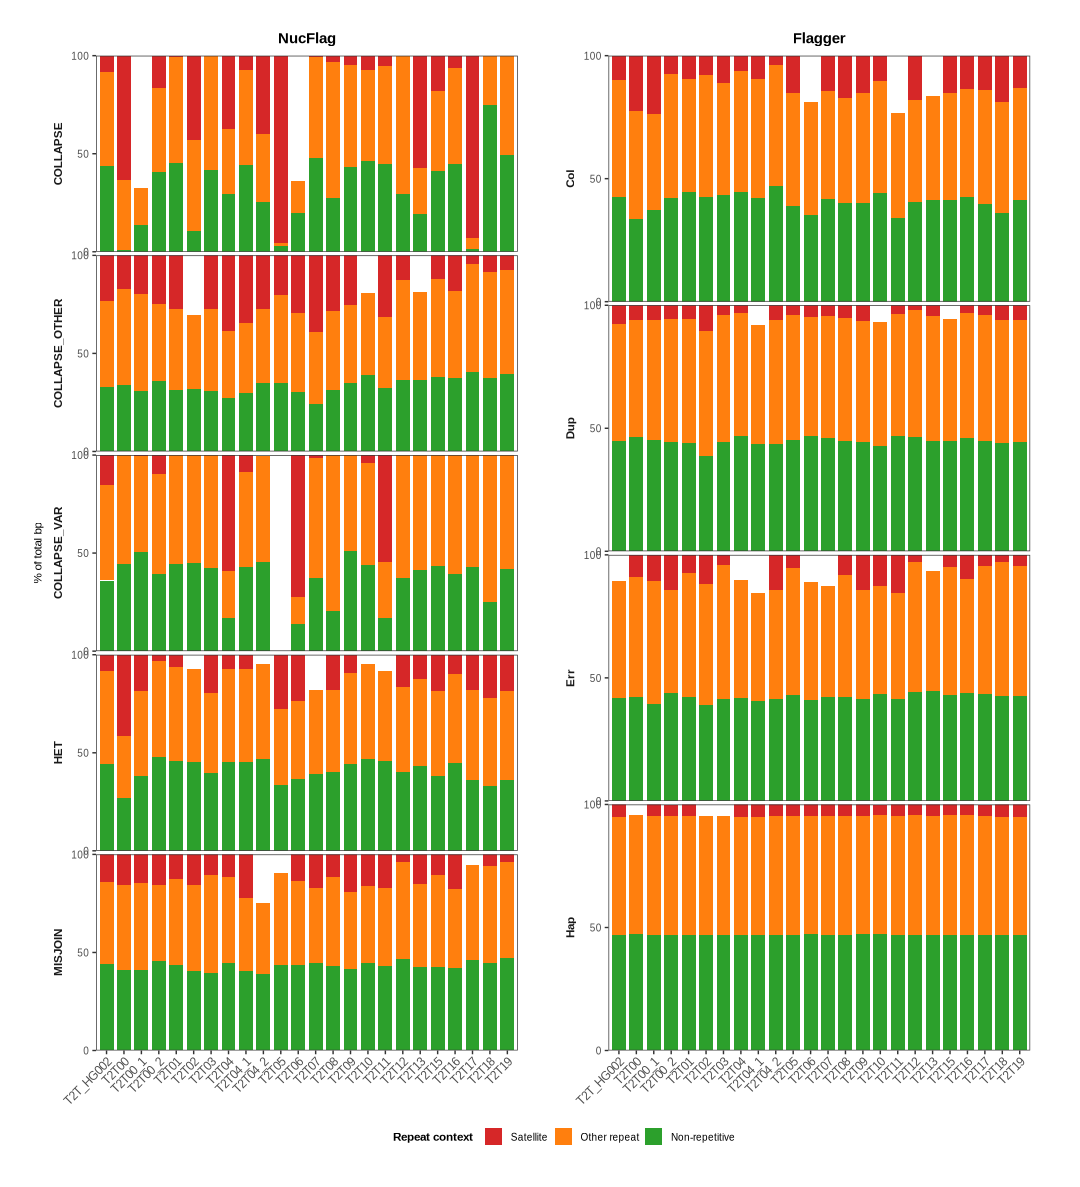

In [21]:
library(patchwork)

n_samples_aic <- length(samples_aic)
n_nf_issues   <- length(unique(aic_summary$issue_type[aic_summary$tool == "nucflag"]))
n_fl_issues   <- length(unique(aic_summary$issue_type[aic_summary$tool == "flagger"]))

make_issue_bar <- function(data, tool_name, title, hide_ylab = FALSE) {
  data |>
    filter(tool == tool_name) |>
    ggplot(aes(x = sample, y = pct_of_total, fill = repeat_class)) +
    geom_col(position = "stack", width = 0.8) +
    facet_grid(issue_type ~ ., scales = "free_y", space = "free_y",
               switch = "y") +
    scale_fill_manual(values = rclass_colours, name = "Repeat context") +
    scale_y_continuous(limits = c(0, 100), expand = c(0, 0), breaks = c(0, 50, 100)) +
    labs(x = NULL, y = if (hide_ylab) NULL else "% of total bp", title = title) +
    t2t_theme(base_size = 9) +
    theme(
      axis.text.x      = element_text(angle = 45, hjust = 1, size = 7),
      strip.placement  = "outside",
      strip.text.y     = element_text(size = 7),
      panel.spacing    = unit(0.15, "lines"),
      legend.position  = "none",
      plot.title       = element_text(size = 9, face = "bold", hjust = 0.5)
    )
}

p_nf <- make_issue_bar(aic_summary, "nucflag", "NucFlag")
p_fl <- make_issue_bar(aic_summary, "flagger", "Flagger", hide_ylab = TRUE)

p_bar <- p_nf + p_fl +
  plot_layout(
    guides  = "collect",
    widths  = c(1, 1),
    heights = n_nf_issues / n_fl_issues   # align row heights proportionally
  ) &
  theme(legend.position = "bottom")

plot_h <- 1.5 + 0.35 * n_samples_aic * max(n_nf_issues, n_fl_issues) / 5

ggsave("../../doc/figures/fig_issue_classification_bar.pdf",
       p_bar, width = 9, height = plot_h, limitsize = FALSE)
ggsave("../../doc/figures/fig_issue_classification_bar.png",
       p_bar, width = 9, height = plot_h, dpi = 200, limitsize = FALSE)

options(repr.plot.width = 9, repr.plot.height = plot_h)
p_bar

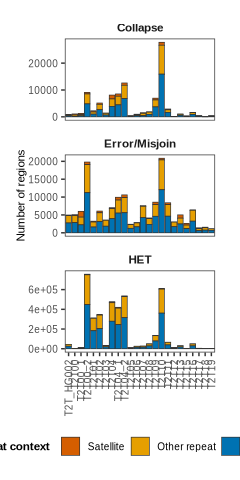

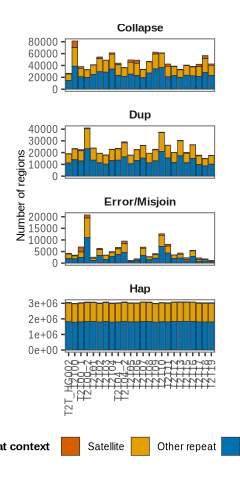

In [22]:
# ── Issue counts by repeat class (replicates fig1_C style, one plot per tool) ─
# Okabe-Ito colorblind-safe palette for repeat classes
rclass_colours_cb <- c(
  Satellite       = "#D55E00",   # vermilion
  `Other repeat`  = "#E69F00",   # amber
  `Non-repetitive` = "#0072B2"   # blue
)

# Derive feature_group from tool + issue_type
aic_classified <- aic_regions |>
  mutate(
    feature_group = case_when(
      issue_type == "MISJOIN"                 ~ "Error/Misjoin",
      tool == "flagger" & issue_type == "Err" ~ "Error/Misjoin",
      grepl("^COLLAPSE", issue_type)          ~ "Collapse",
      tool == "flagger" & issue_type == "Col" ~ "Collapse",
      issue_type == "HET"                     ~ "HET",
      tool == "flagger" & issue_type == "Dup" ~ "Dup",
      TRUE                                    ~ issue_type
    )
  ) |>
  group_by(sample, tool, feature_group, repeat_class) |>
  summarise(n_issues = n(), .groups = "drop")

make_rc_bar <- function(data, tool_name, title) {
  data |>
    filter(tool == tool_name) |>
    ggplot(aes(x = sample, y = n_issues, fill = repeat_class)) +
    geom_col(colour = "grey20", linewidth = 0.2) +
    facet_wrap(~ feature_group, ncol = 1, scales = "free_y") +
    scale_fill_manual(values = rclass_colours_cb, name = "Repeat context") +
    labs(x = NULL, y = "Number of regions") +
    t2t_theme(base_size = 9) +
    theme(
      axis.text.x     = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 6),
      plot.title      = element_text(size = 9, face = "bold", hjust = 0.5),
      legend.position = "bottom"
    )
}

p_nf_rc <- make_rc_bar(aic_classified, "nucflag", "NucFlag")
p_fl_rc <- make_rc_bar(aic_classified, "flagger", "Flagger")

fig1_C_width = 2
fig1_C_height = 4

ggsave("../../doc/figures/fig_issues_by_repeat_class_nucflag.pdf", p_nf_rc, width = fig1_C_width, height = fig1_C_height)
ggsave("../../doc/figures/fig_issues_by_repeat_class_nucflag.png", p_nf_rc, width = fig1_C_width, height = fig1_C_height, dpi = 300)
ggsave("../../doc/figures/fig_issues_by_repeat_class_flagger.pdf", p_fl_rc, width = fig1_C_width, height = fig1_C_height)
ggsave("../../doc/figures/fig_issues_by_repeat_class_flagger.png", p_fl_rc, width = fig1_C_width, height = fig1_C_height, dpi = 300)

options(repr.plot.width = fig1_C_width, repr.plot.height = fig1_C_height); p_nf_rc
options(repr.plot.width = fig1_C_width, repr.plot.height = fig1_C_height); p_fl_rc

In [ ]:
# ── Issue span by repeat class — same layout but y = total bp affected ─────────
aic_classified_bp <- aic_regions |>
  mutate(
    feature_group = case_when(
      issue_type == "MISJOIN"                 ~ "Error/Misjoin",
      tool == "flagger" & issue_type == "Err" ~ "Error/Misjoin",
      grepl("^COLLAPSE", issue_type)          ~ "Collapse",
      tool == "flagger" & issue_type == "Col" ~ "Collapse",
      issue_type == "HET"                     ~ "HET",
      tool == "flagger" & issue_type == "Dup" ~ "Dup",
      TRUE                                    ~ issue_type
    )
  ) |>
  group_by(sample, tool, feature_group, repeat_class) |>
  summarise(total_bp = sum(length_bp), .groups = "drop")

make_rc_bar_bp <- function(data, tool_name) {
  data |>
    filter(tool == tool_name) |>
    ggplot(aes(x = sample, y = total_bp / 1e6, fill = repeat_class)) +
    geom_col(colour = "grey20", linewidth = 0.2) +
    facet_wrap(~ feature_group, ncol = 1, scales = "free_y") +
    scale_fill_manual(values = rclass_colours_cb, name = "Repeat context") +
    labs(x = NULL, y = "Affected sequence (Mb)") +
    t2t_theme(base_size = 9) +
    theme(
      axis.text.x     = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 6),
      plot.title      = element_text(size = 9, face = "bold", hjust = 0.5),
      legend.position = "bottom"
    )
}

p_nf_rc_bp <- make_rc_bar_bp(aic_classified_bp, "nucflag")
p_fl_rc_bp <- make_rc_bar_bp(aic_classified_bp, "flagger")

ggsave("../../doc/figures/fig_issues_by_repeat_class_bp_nucflag.pdf", p_nf_rc_bp, width = fig1_C_width, height = fig1_C_height)
ggsave("../../doc/figures/fig_issues_by_repeat_class_bp_nucflag.png", p_nf_rc_bp, width = fig1_C_width, height = fig1_C_height, dpi = 300)
ggsave("../../doc/figures/fig_issues_by_repeat_class_bp_flagger.pdf", p_fl_rc_bp, width = fig1_C_width, height = fig1_C_height)
ggsave("../../doc/figures/fig_issues_by_repeat_class_bp_flagger.png", p_fl_rc_bp, width = fig1_C_width, height = fig1_C_height, dpi = 300)

options(repr.plot.width = fig1_C_width, repr.plot.height = fig1_C_height); p_nf_rc_bp
options(repr.plot.width = fig1_C_width, repr.plot.height = fig1_C_height); p_fl_rc_bp


## 6) Reviewer sample QC table

Combines flowcell counts, raw read QC (from `doc/tables/flowcell_stats.tsv`),
filtered/HERRO stats (from `assembly/input_qc` histograms), and assembly metrics.

Two outputs: simple reviewer table (Table 1) and extended wide table with all three
read-QC categories (Table 2).

In [23]:
library(flextable)
library(officer)

pub_samples <- c(
  "T2T00", "T2T00_1", "T2T00_2",
  "T2T01", "T2T02", "T2T03",
  "T2T04", "T2T04_1", "T2T04_2",
  "T2T05", "T2T06", "T2T07", "T2T08", "T2T09", "T2T10",
  "T2T11", "T2T12", "T2T13",
  "T2T15", "T2T16", "T2T17", "T2T18", "T2T19"
)

# flowcell_stats.tsv generated by 01_read_qc.ipynb — one row per flowcell
all_fc <- read_tsv("../../doc/tables/flowcell_stats.tsv", show_col_types = FALSE) %>%
  filter(dataset %in% pub_samples)

# raw UL: aggregate yield / N50 / frac / bases >100kb per sample
raw_ul <- all_fc %>%
  filter(sequencing_type == "UltraLong") %>%
  group_by(dataset) %>%
  summarise(
    raw_yield      = as.integer(round(sum(yield) / 1e9)),
    raw_n50        = round(weighted.mean(N50, yield) / 1000, 1),
    raw_frac       = sprintf("%.0f%%", sum(bases_longer_1e5) / sum(yield) * 100),
    raw_bases_100k = round(sum(bases_longer_1e5) / 1e9, 1),
    .groups        = "drop"
  )

# flowcell counts per sample
fc_counts <- all_fc %>%
  group_by(dataset) %>%
  summarise(
    ul_n    = sum(sequencing_type == "UltraLong"),
    porec_n = sum(sequencing_type == "PoreC"),
    lsk_n   = sum(sequencing_type == "LSK"),
    .groups = "drop"
  ) %>%
  mutate(
    ul_fc    = paste0(ul_n, "/", ul_n),
    porec_fc = paste0(pmin(1L, porec_n), "/", porec_n)
  ) %>%
  select(dataset, ul_fc, porec_fc, lsk_fc = lsk_n)

# filtered (UL.70x) and HERRO (HQ_herro.50x) stats from assembly_input_read_stats.tsv
# generated by 05_samples_qc.ipynb
input_stats <- read_tsv("../../doc/tables/for_plots/assembly_input_read_stats.tsv",
                        show_col_types = FALSE) %>%
  filter(sample %in% pub_samples) %>%
  mutate(
    yield_gb = as.integer(round(total_bases / 1e9)),
    n50_kb   = round(N50 / 1000, 1),
    frac     = sprintf("%.0f%%", yield_above_100kb / total_bases * 100)
  )

filt_stats <- input_stats %>%
  filter(type == "UL.70x") %>%
  select(dataset = sample, filt_yield = yield_gb, filt_n50 = n50_kb, filt_frac = frac)

herro_stats <- input_stats %>%
  filter(type == "HQ_herro.50x") %>%
  select(dataset = sample, herro_yield = yield_gb, herro_n50 = n50_kb, herro_frac = frac)

asm_qc <- read_tsv("../../doc/tables/qc_samples_full_wide.tsv", show_col_types = FALSE) %>%
  filter(haplotype == "both") %>%
  select(dataset = asm_name, t2t_contigs = n_t2t_contig, t2t_scaffolds = n_t2t_scaffold)

# Merqury QV — phased_verkko/{sample}/merqury.qv, "both" row, column 4
qv_stats <- tibble(dataset = pub_samples) %>%
  mutate(path = paste0("../../assembly/qc/phased_verkko/", dataset, "/merqury.qv")) %>%
  rowwise() %>%
  mutate(merqury_qv = if (file.exists(path)) {
    qv_tbl <- read_tsv(path,
                       col_names = c("asm", "err_kmers", "total_kmers", "qv", "err_rate"),
                       show_col_types = FALSE)
    round(qv_tbl$qv[qv_tbl$asm == "both"], 1)
  } else {
    NA_real_
  }) %>%
  ungroup() %>%
  select(dataset, merqury_qv) %>%
  # T2T01/T2T10/T2T11 have no individual short-read k-mer truth; QV vs HG002 is not comparable
  mutate(merqury_qv = if_else(dataset %in% c("T2T01", "T2T10", "T2T11"), NA_real_, merqury_qv))

# centromere counts — one bed file per sample
cen_counts <- tibble(dataset = pub_samples) %>%
  mutate(bed = paste0("../../analysis_other/cenmap/results/final/bed/",
                      dataset, "_complete_correct_cens.bed")) %>%
  rowwise() %>%
  mutate(cens = if (file.exists(bed))
                  nrow(read_tsv(bed, col_names = FALSE, show_col_types = FALSE))
                else NA_integer_) %>%
  ungroup() %>%
  select(dataset, cens)

tbl <- tibble(dataset = pub_samples) %>%
  left_join(fc_counts,   by = "dataset") %>%
  left_join(raw_ul,      by = "dataset") %>%
  left_join(filt_stats,  by = "dataset") %>%
  left_join(herro_stats, by = "dataset") %>%
  left_join(asm_qc,      by = "dataset") %>%
  left_join(qv_stats,    by = "dataset") %>%
  left_join(cen_counts,  by = "dataset")

tbl

Warning message:
“package ‘flextable’ was built under R version 4.5.3”

Attaching package: ‘flextable’


The following object is masked from ‘package:purrr’:

    compose


Warning message:
“package ‘officer’ was built under R version 4.5.3”


dataset,ul_fc,porec_fc,lsk_fc,raw_yield,raw_n50,raw_frac,raw_bases_100k,filt_yield,filt_n50,filt_frac,herro_yield,herro_n50,herro_frac,t2t_contigs,t2t_scaffolds,merqury_qv,cens
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>
T2T00,3/3,1/4,0,325,48.0,20%,64.0,89,122.0,72%,160,80.5,35%,17,23,45.0,31
T2T00_1,3/3,1/2,1,237,67.7,28%,66.3,96,115.6,69%,160,85.5,37%,14,22,44.3,30
T2T00_2,3/3,1/2,1,139,77.2,35%,48.7,66,122.1,73%,160,55.0,25%,1,18,44.7,8
T2T01,4/4,1/2,0,173,84.8,41%,71.5,91,135.0,79%,157,79.4,38%,18,18,NA,14
T2T02,4/4,1/2,0,192,100.1,48%,93.2,131,145.6,82%,160,102.2,51%,14,21,44.2,6
T2T03,3/3,1/2,0,180,129.3,63%,112.6,129,166.5,87%,160,131.7,65%,28,11,44.7,20
T2T04,6/6,1/5,0,292,83.1,37%,108.2,138,137.0,79%,160,110.6,58%,15,21,44.3,5
T2T04_1,4/4,1/2,1,169,95.4,45%,76.1,94,140.1,81%,160,83.4,41%,5,31,44.4,5
T2T04_2,5/5,1/2,1,159,94.7,45%,72.0,90,136.3,80%,160,76.0,37%,3,25,44.1,2


In [24]:
# Table 1: simple reviewer table — flowcells + raw read QC + assembly
t1 <- tbl %>%
  select(
    Sample          = dataset,
    UL              = ul_fc,
    PoreC           = porec_fc,
    LSK             = lsk_fc,
    Yield           = raw_yield,
    N50             = raw_n50,
    Frac            = raw_frac,
    `T2T contigs`   = t2t_contigs,
    `T2T scaffolds` = t2t_scaffolds,
    QV              = merqury_qv,
    Cens            = cens
  )

ft1 <- flextable(t1) %>%
  set_header_labels(
    `T2T contigs`   = "T2T\ncontigs",
    `T2T scaffolds` = "T2T\nscaff.",
    QV              = "Merqury\nQV"
  ) %>%
  # units row below column names
  add_header_row(top = FALSE,
    values    = c("", "used/gen", "used/gen", "n", "Gb", "kb", ">100 kb", "", "", "", ""),
    colwidths = rep(1L, 11L)) %>%
  # group row above column names
  add_header_row(top = TRUE,
    values    = c("", "Flowcells", "Raw UL reads", "Assembly"),
    colwidths = c(1L, 3L, 3L, 4L)) %>%
  theme_booktabs() %>%
  align(part = "header", align = "center") %>%
  bold(i = 1:2, part = "header") %>%
  fontsize(i = 3, size = 8, part = "header") %>%
  autofit()

ft1

doc1 <- read_docx() %>% body_add_flextable(ft1)
print(doc1, target = "../../doc/tables/reviewer_sample_qc.docx")

writeLines(c(
  "# Per-Sample Sequencing and Assembly QC",
  "UL = UltraLong ONT. used/gen = flowcells used in assembly / total generated.",
  "Raw UL: pre-filter, all flowcells merged. Yield in Gb, N50 in kb. Cens = complete centromeres.",
  "QV: Merqury k-mer quality value (both haplotypes combined), from phased_verkko assembly.",
  "",
  paste0("| ", paste(names(t1), collapse = " | "), " |"),
  paste0("| ", paste(rep("---", ncol(t1)), collapse = " | "), " |"),
  apply(t1, 1, function(r) paste0("| ", paste(r, collapse = " | "), " |"))
), "../../doc/tables/reviewer_sample_qc.md")


a flextable object.
col_keys: `Sample`, `UL`, `PoreC`, `LSK`, `Yield`, `N50`, `Frac`, `T2T contigs`, `T2T scaffolds`, `QV`, `Cens` 
header has 3 row(s) 
body has 23 row(s) 
original dataset sample: 
'data.frame':	23 obs. of  11 variables:
 $ Sample       : chr  "T2T00" "T2T00_1" "T2T00_2" "T2T01" ...
 $ UL           : chr  "3/3" "3/3" "3/3" "4/4" ...
 $ PoreC        : chr  "1/4" "1/2" "1/2" "1/2" ...
 $ LSK          : int  0 1 1 0 0 0 0 1 1 0 ...
 $ Yield        : int  325 237 139 173 192 180 292 169 159 238 ...
 $ N50          : num  48 67.7 77.2 84.8 100.1 ...
 $ Frac         : chr  "20%" "28%" "35%" "41%" ...
 $ T2T contigs  : num  17 14 1 18 14 28 15 5 3 29 ...
 $ T2T scaffolds: num  23 22 18 18 21 11 21 31 25 11 ...
 $ QV           : num  45 44.3 44.7 NA 44.2 44.7 44.3 44.4 44.1 45.4 ...
 $ Cens         : int  31 30 8 14 6 20 5 5 2 29 ...

In [25]:
# Table 2: wide format — raw + filtered (>=80kb, 70x) + HERRO (50x) + assembly
t2 <- tbl %>%
  select(
    dataset,
    ul_fc, porec_fc, lsk_fc,
    raw_yield, raw_n50, raw_frac,
    filt_yield, filt_n50, filt_frac,
    herro_yield, herro_n50, herro_frac,
    t2t_contigs, t2t_scaffolds, merqury_qv, cens
  )

ft2 <- flextable(t2) %>%
  set_header_labels(
    dataset       = "Sample",
    ul_fc         = "UL",       porec_fc   = "PoreC",  lsk_fc     = "LSK",
    raw_yield     = "Yield",    raw_n50    = "N50",    raw_frac   = "Frac",
    filt_yield    = "Yield",    filt_n50   = "N50",    filt_frac  = "Frac",
    herro_yield   = "Yield",    herro_n50  = "N50",    herro_frac = "Frac",
    t2t_contigs   = "T2T\ncontigs",
    t2t_scaffolds = "T2T\nscaff.",
    merqury_qv    = "Merqury\nQV",
    cens          = "Cens"
  ) %>%
  # units row below column names
  add_header_row(top = FALSE,
    values    = c("", "used/gen", "used/gen", "n",
                  "Gb", "kb", ">100 kb",
                  "Gb", "kb", ">100 kb",
                  "Gb", "kb", ">100 kb",
                  "", "", "", ""),
    colwidths = rep(1L, 17L)) %>%
  # group row above column names
  add_header_row(top = TRUE,
    values    = c("", "Flowcells", "Raw UL", "Filtered ≥80 kb, 70×", "HERRO 50×", "Assembly"),
    colwidths = c(1L, 3L, 3L, 3L, 3L, 4L)) %>%
  theme_booktabs() %>%
  align(part = "header", align = "center") %>%
  bold(i = 1:2, part = "header") %>%
  fontsize(size = 7, part = "all") %>%
  fontsize(i = 3, size = 6, part = "header") %>%
  autofit()

ft2

# landscape A4 docx
ps <- prop_section(page_size = page_size(width = 11.69, height = 8.27, orient = "landscape"))
doc2 <- read_docx() %>%
  body_add_flextable(ft2) %>%
  body_end_block_section(block_section(ps))
print(doc2, target = "../../doc/tables/reviewer_sample_qc_wide.docx")


a flextable object.
col_keys: `dataset`, `ul_fc`, `porec_fc`, `lsk_fc`, `raw_yield`, `raw_n50`, `raw_frac`, `filt_yield`, `filt_n50`, `filt_frac`, `herro_yield`, `herro_n50`, `herro_frac`, `t2t_contigs`, `t2t_scaffolds`, `merqury_qv`, `cens` 
header has 3 row(s) 
body has 23 row(s) 
original dataset sample: 
'data.frame':	23 obs. of  17 variables:
 $ dataset      : chr  "T2T00" "T2T00_1" "T2T00_2" "T2T01" ...
 $ ul_fc        : chr  "3/3" "3/3" "3/3" "4/4" ...
 $ porec_fc     : chr  "1/4" "1/2" "1/2" "1/2" ...
 $ lsk_fc       : int  0 1 1 0 0 0 0 1 1 0 ...
 $ raw_yield    : int  325 237 139 173 192 180 292 169 159 238 ...
 $ raw_n50      : num  48 67.7 77.2 84.8 100.1 ...
 $ raw_frac     : chr  "20%" "28%" "35%" "41%" ...
 $ filt_yield   : int  89 96 66 91 131 129 138 94 90 109 ...
 $ filt_n50     : num  122 116 122 135 146 ...
 $ filt_frac    : chr  "72%" "69%" "73%" "79%" ...
 $ herro_yield  : int  160 160 160 157 160 160 160 160 160 160 ...
 $ herro_n50    : num  80.5 85.5 55 79.4 10

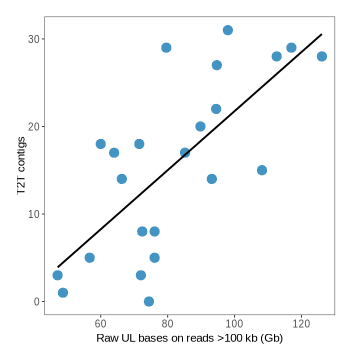

In [26]:
p_bases_t2t <- tbl %>%
  filter(!is.na(raw_bases_100k), !is.na(t2t_contigs)) %>%
  ggplot(aes(x = raw_bases_100k, y = t2t_contigs)) +
  geom_point(size = 2.5, colour = "#4393c3") +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE, colour = "black") +
  labs(x = "Raw UL bases on reads >100 kb (Gb)",
       y = "T2T contigs")
    

ggsave("../../doc/figures/fig_bases100kb_vs_t2t_contigs.pdf", p_bases_t2t, width = 3, height = 3)
ggsave("../../doc/figures/fig_bases100kb_vs_t2t_contigs.png", p_bases_t2t, width = 3, height = 3, dpi = 300)

options(repr.plot.width = 3, repr.plot.height = 3)
p_bases_t2t


## 7) Dip3D contact-pair phasing rate (cohort-wide)

In [31]:
# Contact-pair phasing rate cohort-wide (Dip3D imputed tag)
pub_samples_primary <- pub_samples[!grepl("_[12]$", pub_samples)]

dip3d_contacts <- read_tsv(
  "../../analysis_other/dip3d/combined_dip3d_stats.tsv",
  show_col_types = FALSE
) |>
  filter(tag_type == "imputed", sample %in% pub_samples_primary) |>
  select(sample,
         phased_contacts = contacts_dist_2147483647_phased,
         total_contacts  = contacts_dist_2147483647_total,
         pct_phased      = contacts_dist_2147483647_phased_pct)

print(dip3d_contacts |> arrange(pct_phased), n = Inf)

dip3d_contacts |>
  summarise(
    n_samples         = n(),
    mean_pct          = round(mean(pct_phased), 1),
    median_pct        = round(median(pct_phased), 1),
    min_pct           = round(min(pct_phased), 1),
    max_pct           = round(max(pct_phased), 1),
    weighted_mean_pct = round(sum(phased_contacts) / sum(total_contacts) * 100, 1)
  ) |>
  print()


# A tibble: 19 × 4
   sample phased_contacts total_contacts pct_phased
   <chr>            <dbl>          <dbl>      <dbl>
 1 T2T06       2677885496     3992095915       67.1
 2 T2T02       5417610465     7817961518       69.3
 3 T2T05      12337391061    17185058429       71.8
 4 T2T09       7663114330    10563736600       72.5
 5 T2T01      11958989212    16426531888       72.8
 6 T2T10       8354947450    11437799632       73.0
 7 T2T19      11256797009    14684388810       76.7
 8 T2T18       8755701804    11366997679       77.0
 9 T2T13      38755077977    50147955186       77.3
10 T2T08       9208766718    11746640684       78.4
11 T2T07      19080157460    24304652697       78.5
12 T2T11      18642889067    23643201106       78.9
13 T2T17      15841579207    19943216032       79.4
14 T2T03      15953139041    20051335920       79.6
15 T2T15      21899644638    27356044733       80.1
16 T2T12      56941975018    70518369251       80.7
17 T2T04      36543419300    44804019575     

## 8) Dip3D per-chromosome assignment rate breakdown

Quantifies the individual steps that contribute to the ~46–54% read-level haplotype assignment rate.

Pipeline funnel:
1. **Falign** – all Pore-C reads mapped (100%)
2. **Chr-BAM split** – fragments split by chromosome; coverage mask and quality filters applied *inside* haplotag
3. **SNP tagging** – fragments overlapping phased het SNPs receive a haplotype tag (~12–14% of frags; ~21% of reads per autosome)
4. **Cis-contact imputation** – haplotype propagated to neighbouring fragments within already-tagged reads (raises phased *frags* to ~46%; *read* count unchanged)
5. **Global union** – a read is assigned if tagged on any chromosome (~46% globally vs ~21% per-chromosome)

In [32]:
# ── Parse bam_haplotag logs: SNP-tagged and imputed stats per chromosome ──────
log_dir_haplotag <- "../../logs/dip3d/bam_haplotag"
log_dir_map      <- "../../logs/dip3d/map_reads"
chrs_to_parse    <- c(paste0("chr", 1:22), "chrX")

# Extract first integer after ": " from the first line matching pattern
get_num <- function(lines, pattern) {
  m <- grep(pattern, lines, value = TRUE)
  if (length(m) == 0L) return(NA_integer_)
  as.integer(str_match(m[1L], ": (\\d+)")[, 2L])
}

parse_haplotag_chr <- function(sample, chr) {
  f <- file.path(log_dir_haplotag, paste0(sample, ".", chr, ".bam_haplotag.log"))
  if (!file.exists(f)) return(NULL)
  lines <- readLines(f)

  snp_start <- grep("SNP-tagged frag and contact stats", lines)[1L]
  imp_start <- grep("Imputed frag and contact stats",   lines)[1L]
  if (is.na(snp_start) || is.na(imp_start)) return(NULL)

  snp_lines <- lines[snp_start:(imp_start - 1L)]
  imp_lines <- lines[imp_start:length(lines)]

  tibble(
    sample           = sample,
    chr              = chr,
    total_reads      = get_num(snp_lines, "Total reads:"),
    total_frags      = get_num(snp_lines, "Total frags:"),
    snp_phased_reads = get_num(snp_lines, "Reads with phased frags:"),
    snp_phased_frags = get_num(snp_lines, "Phased frags:"),
    imp_phased_reads = get_num(imp_lines, "Reads with phased frags:"),
    imp_phased_frags = get_num(imp_lines, "Phased frags:")
  )
}

# Total falign reads per sample (sum over batch log lines "Load N sequences")
parse_falign_reads <- function(sample) {
  f <- file.path(log_dir_map, paste0(sample, ".log"))
  if (!file.exists(f)) return(NA_integer_)
  lines <- readLines(f)
  m <- str_extract(grep("Load \\d+ sequences", lines, value = TRUE),
                   "\\d+(?= sequences)")
  sum(as.integer(m), na.rm = TRUE)
}

# Only primary runs that have haplotag logs
pub_samples_primary <- pub_samples[!grepl("_[12]$", pub_samples)]
pub_samples_haplotag <- pub_samples_primary[
  file.exists(file.path(log_dir_haplotag,
    paste0(pub_samples_primary, ".chr1.bam_haplotag.log")))
]

chr_stats <- map_dfr(pub_samples_haplotag, function(s) {
  map_dfr(chrs_to_parse, ~ parse_haplotag_chr(s, .x))
})

falign_reads <- tibble(
  sample       = pub_samples_haplotag,
  falign_reads = map_int(pub_samples_haplotag, parse_falign_reads)
)

cat(sprintf("Parsed %d samples × %d chr = %d rows\n",
    length(pub_samples_haplotag), length(chrs_to_parse), nrow(chr_stats)))

Parsed 19 samples × 23 chr = 437 rows


In [33]:
# ── Per-chromosome funnel (autosomes only; chrX skipped for male hemizygosity) ─

funnel_chr <- chr_stats |>
  filter(chr != "chrX", !is.na(total_reads)) |>
  group_by(sample) |>
  summarise(
    total_reads      = sum(total_reads,      na.rm = TRUE),
    total_frags      = sum(total_frags,      na.rm = TRUE),
    snp_phased_reads = sum(snp_phased_reads, na.rm = TRUE),
    snp_phased_frags = sum(snp_phased_frags, na.rm = TRUE),
    imp_phased_frags = sum(imp_phased_frags, na.rm = TRUE),
    .groups = "drop"
  ) |>
  mutate(
    pct_snp_reads = 100 * snp_phased_reads / total_reads,
    pct_snp_frags = 100 * snp_phased_frags / total_frags,
    pct_imp_frags = 100 * imp_phased_frags / total_frags
  )

# ── Global read-level assignment + contact phasing from combined_dip3d_stats.tsv
dip3d_combined <- read_tsv(
  "../../analysis_other/dip3d/combined_dip3d_stats.tsv",
  show_col_types = FALSE
) |>
  filter(tag_type == "imputed", sample %in% pub_samples_haplotag) |>
  select(sample,
         global_phased_reads     = reads_with_phased_frags,
         pct_global              = reads_with_phased_frags_pct,
         pct_phased_contacts     = contacts_dist_2147483647_phased_pct)

# ── Combined funnel table ──────────────────────────────────────────────────────
funnel <- funnel_chr |>
  left_join(falign_reads,  by = "sample") |>
  left_join(dip3d_combined, by = "sample") |>
  transmute(
    sample,
    falign_reads,
    snp_phased_reads,
    pct_snp_reads        = round(pct_snp_reads,        1),
    snp_phased_frags,
    pct_snp_frags        = round(pct_snp_frags,        1),
    imp_phased_frags,
    pct_imp_frags        = round(pct_imp_frags,        1),
    global_phased_reads,
    pct_global           = round(pct_global,           1),
    pct_phased_contacts  = round(pct_phased_contacts,  1)
  )

print(funnel |> select(sample, pct_snp_reads, pct_snp_frags, pct_imp_frags,
                        pct_global, pct_phased_contacts))

# Cohort summary
funnel |>
  summarise(
    n_samples                = n(),
    mean_pct_snp_reads       = round(mean(pct_snp_reads,       na.rm = TRUE), 1),
    mean_pct_snp_frags       = round(mean(pct_snp_frags,       na.rm = TRUE), 1),
    mean_pct_imp_frags       = round(mean(pct_imp_frags,       na.rm = TRUE), 1),
    mean_pct_global          = round(mean(pct_global,          na.rm = TRUE), 1),
    mean_pct_phased_contacts = round(mean(pct_phased_contacts, na.rm = TRUE), 1)
  ) |>
  print()

# ── Export (clean TSV, no comment header) ─────────────────────────────────────
out_path <- "../../doc/tables/dip3d_assignment_funnel.tsv"
write_tsv(funnel, out_path)
cat("Written to", out_path, "\n")

# A tibble: 19 × 6
   sample pct_snp_reads pct_snp_frags pct_imp_frags pct_global
   <chr>          <dbl>         <dbl>         <dbl>      <dbl>
 1 T2T00           21.1          12.9          47.3       46.4
 2 T2T01           23.5          13.4          44.4       46.7
 3 T2T02           17            12.5          30.6       44  
 4 T2T03           24.1          13.9          49.1       51.5
 5 T2T04           19.9          12.7          45.5       44.7
 6 T2T05           23.4          13.3          44.2       44.3
 7 T2T06           16.2          12.4          27.6       43.3
 8 T2T07           24.5          13.6          49.6       52.1
 9 T2T08           17.4          12.4          37         45.4
10 T2T09           16.4          12.5          29.7       44.9
11 T2T10           17.3          12.7          32.7       43.3
12 T2T11           23.3          13.3          48.1       51.4
13 T2T12           24.6          13.6          51         48.9
14 T2T13           21.2          12.